# Nexus Mods Rewards Data Analysis

This notebook parses, cleans, and analyzes Nexus Mods rewards data from CSV format.

It includes data cleaning, statistical analysis, trend analysis, forecasting, outlier detection, and comprehensive visualizations.

## 1. Import Required Libraries and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime, timedelta
from typing import List, Tuple, Optional, Dict
import os
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ============================================
# CONFIGURATION CONSTANTS
# ============================================
MA_WINDOW_SHORT = 3
MA_WINDOW_LONG = 6
ZSCORE_THRESHOLD = 3.0
FORECAST_PERIODS = 6
IQR_MULTIPLIER = 1.5

# Color palette
COLOR_DOWNLOADS = '#2E86AB'
COLOR_REWARDS = '#A23B72'
COLOR_YOUR_REWARD = '#F18F01'
COLOR_MA_SHORT = '#F18F01'
COLOR_MA_LONG = '#C73E1D'
COLOR_POSITIVE = 'green'
COLOR_NEGATIVE = 'red'

# Data file path
DATA_FILE = 'nexusmods_rewards.csv'

# Output directory
output_dir = 'analysis_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")
else:
    print(f"Using existing output directory: {output_dir}")

print("Configuration loaded successfully!")

Using existing output directory: analysis_output
Configuration loaded successfully!


## 2. Define Reusable Functions

In [2]:
def parse_nexusmods_data(file_path: str) -> pd.DataFrame:
    """
    Parse and clean Nexus Mods rewards data from CSV file.
    
    
    The CSV file has following columns:
    - Month (date in format like 'Nov 2025')
    - Unique Downloads (negative values, to be ignored)
    - Downloads (actual download count, keep as-is)
    - Mod Rewards (total rewards)
    - Your Reward (your personal rewards)
    
    
    Parameters:
    -----------
    file_path : str
        Path to CSV file containing data
    
    
    Returns:
    --------
    pd.DataFrame
        Clean DataFrame with Month, Downloads, Mod Rewards, and Your Reward columns
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found: {file_path}")
    
    
    # Read CSV file
    df = pd.read_csv(file_path)
    
    
    # Parse Month column (format: 'Nov 2025')
    df['Month'] = pd.to_datetime(df['Month'], format='%b %Y')
    
    
    # Drop 'Unique Downloads' column (it has negative values, should be ignored)
    df = df.drop(columns=['Unique Downloads'], errors='ignore')
    
    
    # Sort by month and set index
    df = df.sort_values('Month').reset_index(drop=True)
    df.set_index('Month', inplace=True)
    
    
    return df

In [3]:
def detect_outliers_iqr(data: pd.Series, multiplier: float = IQR_MULTIPLIER) -> pd.Series:
    """
    Detect outliers using the IQR method.
    
    Parameters:
    -----------
    data : pd.Series
        Data series to analyze
    multiplier : float
        IQR multiplier (default: 1.5)
    
    Returns:
    --------
    pd.Series
        Boolean series indicating outliers (True = outlier)
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (data < lower_bound) | (data > upper_bound)

In [4]:
def detect_outliers_zscore(data: pd.Series, threshold: float = ZSCORE_THRESHOLD) -> pd.Series:
    """
    Detect outliers using the Z-score method.
    
    Parameters:
    -----------
    data : pd.Series
        Data series to analyze
    threshold : float
        Z-score threshold (default: 3.0)
    
    Returns:
    --------
    pd.Series
        Boolean series indicating outliers (True = outlier)
    """
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

In [5]:
def forecast_linear_trend(data: pd.Series, periods: int = FORECAST_PERIODS) -> Tuple[pd.Series, pd.Series, pd.DataFrame]:
    """
    Forecast future values using linear trend extrapolation.
    
    Parameters:
    -----------
    data : pd.Series
        Historical data series
    periods : int
        Number of periods to forecast
    
    Returns:
    --------
    Tuple[pd.Series, pd.Series, pd.DataFrame]
        (forecast_dates, forecast_values, confidence_intervals)
    """
    x = np.arange(len(data))
    y = data.values
    
    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Generate forecast
    x_forecast = np.arange(len(data), len(data) + periods)
    forecast_values = slope * x_forecast + intercept
    
    # Calculate confidence intervals (95%)
    confidence = 1.96 * std_err * np.sqrt(1 + 1/len(data) + (x_forecast - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    lower_bound = forecast_values - confidence
    upper_bound = forecast_values + confidence
    
    # Generate forecast dates
    forecast_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=periods, freq='MS')
    
    return forecast_dates, pd.Series(forecast_values, index=forecast_dates), \
           pd.DataFrame({'lower': lower_bound, 'upper': upper_bound}, index=forecast_dates)

In [6]:
def forecast_moving_average(data: pd.Series, window: int = MA_WINDOW_SHORT, periods: int = FORECAST_PERIODS) -> Tuple[pd.Series, pd.Series]:
    """
    Forecast future values using moving average.
    
    Parameters:
    -----------
    data : pd.Series
        Historical data series
    window : int
        Moving average window size
    periods : int
        Number of periods to forecast
    
    Returns:
    --------
    Tuple[pd.Series, pd.Series]
        (forecast_dates, forecast_values)
    """
    forecast_values = []
    extended_data = data.copy().tolist()
    
    for _ in range(periods):
        next_value = np.mean(extended_data[-window:])
        extended_data.append(next_value)
        forecast_values.append(next_value)
    
    forecast_dates = pd.date_range(start=data.index[-1] + timedelta(days=32), 
                                  periods=periods, freq='MS')
    
    return forecast_dates, pd.Series(forecast_values, index=forecast_dates)

In [7]:
def validate_data(df: pd.DataFrame) -> Dict[str, any]:
    """
    Validate data quality and return a report.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to validate
    
    Returns:
    --------
    Dict
        Validation report with issues found
    """
    report = {
        'missing_values': df.isnull().sum().sum(),
        'negative_downloads': (df['Downloads'] < 0).sum(),
        'negative_rewards': (df['Mod Rewards'] < 0).sum(),
        'negative_your_reward': (df['Your Reward'] < 0).sum(),
        'duplicate_dates': df.index.duplicated().sum(),
        'total_records': len(df),
        'date_range': (df.index.min(), df.index.max()),
        'issues': []
    }
    
    if report['missing_values'] > 0:
        report['issues'].append(f"Found {report['missing_values']} missing values")
    if report['negative_downloads'] > 0:
        report['issues'].append(f"Found {report['negative_downloads']} negative download values")
    if report['negative_rewards'] > 0:
        report['issues'].append(f"Found {report['negative_rewards']} negative reward values")
    if report['negative_your_reward'] > 0:
        report['issues'].append(f"Found {report['negative_your_reward']} negative your reward values")
    if report['duplicate_dates'] > 0:
        report['issues'].append(f"Found {report['duplicate_dates']} duplicate dates")
    
    return report

In [8]:
def calculate_mann_kendall(data: pd.Series) -> Dict[str, any]:
    """
    Perform Mann-Kendall trend test.
    
    Parameters:
    -----------
    data : pd.Series
        Data series to test
    
    Returns:
    --------
    Dict
        Test results including p-value and trend direction
    """
    n = len(data)
    S = 0
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            S += np.sign(data.iloc[j] - data.iloc[i])
    
    # Calculate variance
    unique_counts = data.value_counts()
    var_S = n * (n - 1) * (2 * n + 5) / 18
    for count in unique_counts:
        if count > 1:
            var_S -= count * (count - 1) * (2 * count + 5) / 18
    
    # Calculate Z-score
    if S > 0:
        Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(var_S)
    else:
        Z = 0
    
    # Calculate p-value (two-tailed)
    p_value = 2 * (1 - stats.norm.cdf(abs(Z)))
    
    # Determine trend
    alpha = 0.05
    if p_value < alpha:
        if S > 0:
            trend = 'Increasing'
        else:
            trend = 'Decreasing'
    else:
        trend = 'No significant trend'
    
    return {
        'p_value': p_value,
        'trend': trend,
        'significant': p_value < alpha,
        'S': S,
        'Z': Z
    }

In [9]:
print("Reusable functions defined successfully!")

Reusable functions defined successfully!


## 3. Load and Clean the Data

In [10]:
# Load data
df = parse_nexusmods_data(DATA_FILE)

# Validate data
validation_report = validate_data(df)

# Display first few rows
print("Data Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nLast 10 rows:")
print(df.tail(10))

# Display validation report
print("\n" + "="*70)
print("DATA VALIDATION REPORT")
print("="*70)
print(f"Total Records: {validation_report['total_records']}")
print(f"Date Range: {validation_report['date_range'][0].strftime('%B %Y')} to {validation_report['date_range'][1].strftime('%B %Y')}")
print(f"Missing Values: {validation_report['missing_values']}")
print(f"Negative Downloads: {validation_report['negative_downloads']}")
print(f"Negative Rewards: {validation_report['negative_rewards']}")
print(f"Negative Your Reward: {validation_report['negative_your_reward']}")
print(f"Duplicate Dates: {validation_report['duplicate_dates']}")

if validation_report['issues']:
    print("\nIssues Found:")
    for issue in validation_report['issues']:
        print(f"  - {issue}")
else:
    print("\nNo data quality issues found!")

Data Shape: (62, 3)

First 10 rows:
            Downloads  Mod Rewards  Your Reward
Month                                          
2020-10-01        327          327          327
2020-11-01       2780         2780         2780
2020-12-01       7896         5609         5609
2021-01-01       9166         7898         7898
2021-02-01      11253         9865         9865
2021-03-01      13658        12609        12609
2021-04-01      17723        15653        15653
2021-05-01      15074        12984        12984
2021-06-01      16633        15002        15002
2021-07-01      20955        19021        19021

Last 10 rows:
            Downloads  Mod Rewards  Your Reward
Month                                          
2025-02-01      59790        59701        59701
2025-03-01      52050        51910        51910
2025-04-01      55143        54991        54991
2025-05-01      54348        54196        54196
2025-06-01      44106        43970        43970
2025-07-01      33149        33037   

## 4. Calculate Rolling Statistics and Growth Rates

In [11]:
# Calculate moving averages
df['Downloads MA_3'] = df['Downloads'].rolling(window=MA_WINDOW_SHORT, min_periods=1).mean()
df['Downloads MA_6'] = df['Downloads'].rolling(window=MA_WINDOW_LONG, min_periods=1).mean()
df['Rewards MA_3'] = df['Mod Rewards'].rolling(window=MA_WINDOW_SHORT, min_periods=1).mean()
df['Rewards MA_6'] = df['Mod Rewards'].rolling(window=MA_WINDOW_LONG, min_periods=1).mean()
df['YourReward MA_3'] = df['Your Reward'].rolling(window=MA_WINDOW_SHORT, min_periods=1).mean()

# Calculate rolling standard deviation
df['Downloads Std_3'] = df['Downloads'].rolling(window=MA_WINDOW_SHORT, min_periods=1).std()
df['Rewards Std_3'] = df['Mod Rewards'].rolling(window=MA_WINDOW_SHORT, min_periods=1).std()

# Calculate growth rates
df['Downloads Growth %'] = df['Downloads'].pct_change() * 100
df['Rewards Growth %'] = df['Mod Rewards'].pct_change() * 100
df['YourReward Growth %'] = df['Your Reward'].pct_change() * 100

# Calculate year-over-year growth
df['Downloads YoY Growth %'] = df['Downloads'].pct_change(12) * 100
df['Rewards YoY Growth %'] = df['Mod Rewards'].pct_change(12) * 100

# Calculate reward efficiency (rewards per download)
df['Rewards per Download'] = df['Mod Rewards'] / df['Downloads']
df['YourReward per Download'] = df['Your Reward'] / df['Downloads']
df['YourReward Share %'] = (df['Your Reward'] / df['Mod Rewards']) * 100

# Calculate rolling correlation
df['Rolling Correlation'] = df['Downloads'].rolling(window=6).corr(df['Mod Rewards'])

# Calculate cumulative totals
df['Cumulative Downloads'] = df['Downloads'].cumsum()
df['Cumulative Rewards'] = df['Mod Rewards'].cumsum()
df['Cumulative YourReward'] = df['Your Reward'].cumsum()

# Add year, quarter, and month columns
df['Year'] = df.index.year
df['Quarter'] = df.index.quarter
df['Month_Name'] = df.index.strftime('%B')
df['Month_Num'] = df.index.month

# Display first few rows with new columns
print("\nData with Rolling Statistics (first 10 rows):")
print(df[['Downloads', 'Downloads MA_3', 'Downloads MA_6', 
          'Mod Rewards', 'Rewards MA_3', 'Rewards MA_6',
          'Your Reward', 'YourReward MA_3', 'Rewards per Download']].head(10))


Data with Rolling Statistics (first 10 rows):
            Downloads  Downloads MA_3  Downloads MA_6  Mod Rewards  \
Month                                                                
2020-10-01        327          327.00          327.00          327   
2020-11-01       2780        1,553.50        1,553.50         2780   
2020-12-01       7896        3,667.67        3,667.67         5609   
2021-01-01       9166        6,614.00        5,042.25         7898   
2021-02-01      11253        9,438.33        6,284.40         9865   
2021-03-01      13658       11,359.00        7,513.33        12609   
2021-04-01      17723       14,211.33       10,412.67        15653   
2021-05-01      15074       15,485.00       12,461.67        12984   
2021-06-01      16633       16,476.67       13,917.83        15002   
2021-07-01      20955       17,554.00       15,882.67        19021   

            Rewards MA_3  Rewards MA_6  Your Reward  YourReward MA_3  \
Month                                   

## 5. Quarterly Aggregation

In [12]:
# Calculate quarterly statistics
quarterly_stats = df.groupby(['Year', 'Quarter']).agg({
    'Downloads': ['sum', 'mean', 'std'],
    'Mod Rewards': ['sum', 'mean', 'std'],
    'Your Reward': ['sum', 'mean', 'std'],
    'Rewards per Download': 'mean'
}).round(2)

# Flatten column names
quarterly_stats.columns = ['_'.join(col).strip() for col in quarterly_stats.columns.values]
quarterly_stats = quarterly_stats.reset_index()

# Calculate quarter-over-quarter growth
quarterly_stats['Downloads QoQ Growth %'] = quarterly_stats['Downloads_sum'].pct_change() * 100
quarterly_stats['Rewards QoQ Growth %'] = quarterly_stats['Mod Rewards_sum'].pct_change() * 100

# Save quarterly stats
quarterly_stats.to_csv(f'{output_dir}/nexusmods_quarterly_stats.csv', index=False)

print("\n" + "="*70)
print("QUARTERLY STATISTICS")
print("="*70)
print(quarterly_stats.to_string(index=False))


QUARTERLY STATISTICS
 Year  Quarter  Downloads_sum  Downloads_mean  Downloads_std  Mod Rewards_sum  Mod Rewards_mean  Mod Rewards_std  Your Reward_sum  Your Reward_mean  Your Reward_std  Rewards per Download_mean  Downloads QoQ Growth %  Rewards QoQ Growth %
 2020        4          11003        3,667.67       3,861.79             8716          2,905.33         2,643.23             8716          2,905.33         2,643.23                       0.90                     NaN                   NaN
 2021        1          34077       11,359.00       2,247.88            30372         10,124.00         2,366.16            30372         10,124.00         2,366.16                       0.89                  209.71                248.46
 2021        2          49430       16,476.67       1,331.40            43639         14,546.33         1,391.62            43639         14,546.33         1,391.62                       0.88                   45.05                 43.68
 2021        3         102

## 6. Outlier Detection

In [13]:
# Detect outliers using IQR method
df['Downloads Outlier'] = detect_outliers_iqr(df['Downloads']) | detect_outliers_zscore(df['Downloads'])
df['Rewards Outlier'] = detect_outliers_iqr(df['Mod Rewards']) | detect_outliers_zscore(df['Mod Rewards'])
df['YourReward Outlier'] = detect_outliers_iqr(df['Your Reward']) | detect_outliers_zscore(df['Your Reward'])

# Print outlier summary
print("\n" + "="*70)
print("OUTLIER DETECTION SUMMARY")
print("="*70)
print(f"\nDownloads Outliers: {df['Downloads Outlier'].sum()} months")
print(f"Rewards Outliers: {df['Rewards Outlier'].sum()} months")
print(f"Your Reward Outliers: {df['YourReward Outlier'].sum()} months")

# Show outlier months
if df['Downloads Outlier'].any():
    print("\nDownloads Outlier Months:")
    outlier_months = df[df['Downloads Outlier']][['Downloads', 'Downloads Growth %']]
    outlier_months['Month'] = outlier_months.index.strftime('%B %Y')
    print(outlier_months[['Month', 'Downloads', 'Downloads Growth %']].to_string(index=False))

if df['Rewards Outlier'].any():
    print("\nRewards Outlier Months:")
    outlier_months = df[df['Rewards Outlier']][['Mod Rewards', 'Rewards Growth %']]
    outlier_months['Month'] = outlier_months.index.strftime('%B %Y')
    print(outlier_months[['Month', 'Mod Rewards', 'Rewards Growth %']].to_string(index=False))

if df['YourReward Outlier'].any():
    print("\nYour Reward Outlier Months:")
    outlier_months = df[df['YourReward Outlier']][['Your Reward', 'YourReward Growth %']]
    outlier_months['Month'] = outlier_months.index.strftime('%B %Y')
    print(outlier_months[['Month', 'Your Reward', 'YourReward Growth %']].to_string(index=False))


OUTLIER DETECTION SUMMARY

Downloads Outliers: 4 months
Rewards Outliers: 4 months
Your Reward Outliers: 4 months

Downloads Outlier Months:
        Month  Downloads  Downloads Growth %
 October 2023     115350               86.65
November 2023     117985                2.28
December 2023     113373               -3.91
 January 2024     105503               -6.94

Rewards Outlier Months:
        Month  Mod Rewards  Rewards Growth %
 October 2023       114934             87.84
November 2023       117424              2.17
December 2023       112906             -3.85
 January 2024       104948             -7.05

Your Reward Outlier Months:
        Month  Your Reward  YourReward Growth %
 October 2023       114934                87.84
November 2023       117424                 2.17
December 2023       112906                -3.85
 January 2024       104948                -7.05


## 7. Predictive Forecasting

In [14]:
# Generate forecasts using linear trend
dl_forecast_dates, dl_forecast_values, dl_confidence = forecast_linear_trend(df['Downloads'], periods=FORECAST_PERIODS)
rw_forecast_dates, rw_forecast_values, rw_confidence = forecast_linear_trend(df['Mod Rewards'], periods=FORECAST_PERIODS)
yr_forecast_dates, yr_forecast_values, yr_confidence = forecast_linear_trend(df['Your Reward'], periods=FORECAST_PERIODS)

# Moving average forecast
dl_ma_dates, dl_ma_forecast = forecast_moving_average(df['Downloads'], window=MA_WINDOW_SHORT, periods=FORECAST_PERIODS)
rw_ma_dates, rw_ma_forecast = forecast_moving_average(df['Mod Rewards'], window=MA_WINDOW_SHORT, periods=FORECAST_PERIODS)
yr_ma_dates, yr_ma_forecast = forecast_moving_average(df['Your Reward'], window=MA_WINDOW_SHORT, periods=FORECAST_PERIODS)

print("\n" + "="*70)
print("FORECAST SUMMARY")
print("="*70)
print(f"\nForecasting {FORECAST_PERIODS} months ahead from {df.index[-1].strftime('%B %Y')}")

print(f"\nDownloads Forecast (Linear Trend):")
for i in range(FORECAST_PERIODS):
    date = dl_forecast_dates[i]
    value = dl_forecast_values.iloc[i]
    lower = dl_confidence['lower'].iloc[i]
    upper = dl_confidence['upper'].iloc[i]
    print(f"  {date.strftime('%B %Y')}: {value:,.0f} (95% CI: {lower:,.0f} - {upper:,.0f})")

print(f"\nRewards Forecast (Linear Trend):")
for i in range(FORECAST_PERIODS):
    date = rw_forecast_dates[i]
    value = rw_forecast_values.iloc[i]
    lower = rw_confidence['lower'].iloc[i]
    upper = rw_confidence['upper'].iloc[i]
    print(f"  {date.strftime('%B %Y')}: {value:,.0f} (95% CI: {lower:,.0f} - {upper:,.0f})")

print(f"\nYour Reward Forecast (Linear Trend):")
for i in range(FORECAST_PERIODS):
    date = yr_forecast_dates[i]
    value = yr_forecast_values.iloc[i]
    lower = yr_confidence['lower'].iloc[i]
    upper = yr_confidence['upper'].iloc[i]
    print(f"  {date.strftime('%B %Y')}: {value:,.0f} (95% CI: {lower:,.0f} - {upper:,.0f})")


FORECAST SUMMARY

Forecasting 6 months ahead from November 2025

Downloads Forecast (Linear Trend):
  December 2025: 70,219 (95% CI: 69,897 - 70,541)
  January 2026: 70,984 (95% CI: 70,662 - 71,306)
  February 2026: 71,749 (95% CI: 71,426 - 72,072)
  March 2026: 72,515 (95% CI: 72,191 - 72,838)
  April 2026: 73,280 (95% CI: 72,956 - 73,604)
  May 2026: 74,046 (95% CI: 73,721 - 74,370)

Rewards Forecast (Linear Trend):
  December 2025: 70,362 (95% CI: 70,042 - 70,683)
  January 2026: 71,172 (95% CI: 70,851 - 71,493)
  February 2026: 71,982 (95% CI: 71,661 - 72,303)
  March 2026: 72,792 (95% CI: 72,470 - 73,114)
  April 2026: 73,602 (95% CI: 73,279 - 73,924)
  May 2026: 74,412 (95% CI: 74,089 - 74,734)

Your Reward Forecast (Linear Trend):
  December 2025: 70,362 (95% CI: 70,042 - 70,683)
  January 2026: 71,172 (95% CI: 70,851 - 71,493)
  February 2026: 71,982 (95% CI: 71,661 - 72,303)
  March 2026: 72,792 (95% CI: 72,470 - 73,114)
  April 2026: 73,602 (95% CI: 73,279 - 73,924)
  May 20

## 8. Statistical Summary and Trend Analysis

In [15]:
# Calculate key statistics
total_rewards = df['Mod Rewards'].sum()
total_your_reward = df['Your Reward'].sum()
total_downloads = df['Downloads'].sum()

mean_downloads = df['Downloads'].mean()
median_downloads = df['Downloads'].median()
std_downloads = df['Downloads'].std()

mean_rewards = df['Mod Rewards'].mean()
median_rewards = df['Mod Rewards'].median()
std_rewards = df['Mod Rewards'].std()

mean_your_reward = df['Your Reward'].mean()
median_your_reward = df['Your Reward'].median()

# Peak performance
peak_downloads_month = df['Downloads'].idxmax()
peak_downloads_value = df['Downloads'].max()
peak_rewards_month = df['Mod Rewards'].idxmax()
peak_rewards_value = df['Mod Rewards'].max()
lowest_downloads_month = df['Downloads'].idxmin()
lowest_downloads_value = df['Downloads'].min()

# Growth statistics
avg_monthly_growth_downloads = df['Downloads Growth %'].mean()
avg_monthly_growth_rewards = df['Rewards Growth %'].mean()
avg_yoy_growth_downloads = df['Downloads YoY Growth %'].mean()
avg_yoy_growth_rewards = df['Rewards YoY Growth %'].mean()

# Correlation
correlation = df['Downloads'].corr(df['Mod Rewards'])
your_reward_correlation = df['Downloads'].corr(df['Your Reward'])

# Mann-Kendall trend tests
mk_downloads = calculate_mann_kendall(df['Downloads'])
mk_rewards = calculate_mann_kendall(df['Mod Rewards'])
mk_your_reward = calculate_mann_kendall(df['Your Reward'])

# Reward efficiency
avg_rewards_per_download = df['Rewards per Download'].mean()
avg_your_reward_share = df['YourReward Share %'].mean()

# Display statistical summary
print("="*70)
print("NEXUS MODS REWARDS - STATISTICAL SUMMARY")
print("="*70)
print(f"\nData Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Total Months: {len(df)}")
print()
print("--- TOTALS ---")
print(f"Total Mod Rewards: {total_rewards:,} points")
print(f"Total Your Reward: {total_your_reward:,} points")
print(f"Total Downloads: {total_downloads:,}")
print(f"Your Reward Share: {(total_your_reward/total_rewards)*100:.2f}%")
print()
print("--- DOWNLOADS STATISTICS ---")
print(f"Mean Downloads: {mean_downloads:,.2f}")
print(f"Median Downloads: {median_downloads:,.2f}")
print(f"Std Dev of Downloads: {std_downloads:,.2f}")
print(f"Coefficient of Variation: {(std_downloads/mean_downloads)*100:.2f}%")
print()
print("--- REWARDS STATISTICS ---")
print(f"Mean Mod Rewards: {mean_rewards:,.2f}")
print(f"Median Mod Rewards: {median_rewards:,.2f}")
print(f"Std Dev of Rewards: {std_rewards:,.2f}")
print(f"Coefficient of Variation: {(std_rewards/mean_rewards)*100:.2f}%")
print()
print("--- YOUR REWARD STATISTICS ---")
print(f"Mean Your Reward: {mean_your_reward:,.2f}")
print(f"Median Your Reward: {median_your_reward:,.2f}")
print(f"Average Share of Total Rewards: {avg_your_reward_share:.2f}%")
print()
print("--- REWARD EFFICIENCY ---")
print(f"Average Rewards per Download: {avg_rewards_per_download:.4f}")
print()
print("--- PEAK PERFORMANCE ---")
print(f"Peak Downloads Month: {peak_downloads_month.strftime('%B %Y')}")
print(f"Peak Downloads Value: {peak_downloads_value:,}")
print()
print(f"Peak Rewards Month: {peak_rewards_month.strftime('%B %Y')}")
print(f"Peak Rewards Value: {peak_rewards_value:,}")
print()
print(f"Lowest Downloads Month: {lowest_downloads_month.strftime('%B %Y')}")
print(f"Lowest Downloads Value: {lowest_downloads_value:,}")
print()
print("--- GROWTH ANALYSIS ---")
print(f"Average Monthly Growth (Downloads): {avg_monthly_growth_downloads:.2f}%")
print(f"Average Monthly Growth (Rewards): {avg_monthly_growth_rewards:.2f}%")
print(f"Average YoY Growth (Downloads): {avg_yoy_growth_downloads:.2f}%")
print(f"Average YoY Growth (Rewards): {avg_yoy_growth_rewards:.2f}%")
print()
print("--- CORRELATION ---")
print(f"Downloads-Rewards Correlation: {correlation:.4f}")
print(f"Downloads-YourReward Correlation: {your_reward_correlation:.4f}")
print(f"Correlation Strength: {'Very Strong' if abs(correlation) > 0.8 else 'Strong' if abs(correlation) > 0.6 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'}")
print()
print("--- TREND ANALYSIS (Mann-Kendall Test) ---")
print(f"Downloads Trend: {mk_downloads['trend']} (p-value: {mk_downloads['p_value']:.4f})")
print(f"Rewards Trend: {mk_rewards['trend']} (p-value: {mk_rewards['p_value']:.4f})")
print(f"Your Reward Trend: {mk_your_reward['trend']} (p-value: {mk_your_reward['p_value']:.4f})")
print("="*70)

NEXUS MODS REWARDS - STATISTICAL SUMMARY

Data Period: October 2020 to November 2025
Total Months: 62

--- TOTALS ---
Total Mod Rewards: 2,780,871 points
Total Your Reward: 2,780,871 points
Total Downloads: 2,858,686
Your Reward Share: 100.00%

--- DOWNLOADS STATISTICS ---
Mean Downloads: 46,107.84
Median Downloads: 43,277.50
Std Dev of Downloads: 26,173.13
Coefficient of Variation: 56.77%

--- REWARDS STATISTICS ---
Mean Mod Rewards: 44,852.76
Median Mod Rewards: 40,396.00
Std Dev of Rewards: 26,513.89
Coefficient of Variation: 59.11%

--- YOUR REWARD STATISTICS ---
Mean Your Reward: 44,852.76
Median Your Reward: 40,396.00
Average Share of Total Rewards: 100.00%

--- REWARD EFFICIENCY ---
Average Rewards per Download: 0.9577

--- PEAK PERFORMANCE ---
Peak Downloads Month: November 2023
Peak Downloads Value: 117,985

Peak Rewards Month: November 2023
Peak Rewards Value: 117,424

Lowest Downloads Month: October 2020
Lowest Downloads Value: 327

--- GROWTH ANALYSIS ---
Average Monthly Gr

## 9. Milestone Tracking

In [16]:
# Define milestones
download_milestones = [10000, 50000, 100000, 500000, 1000000]
reward_milestones = [10000, 50000, 100000, 500000, 1000000]

# Find when milestones were reached
download_milestones_reached = []
for milestone in download_milestones:
    milestone_data = df[df['Cumulative Downloads'] >= milestone]
    if not milestone_data.empty:
        first_reached = milestone_data.index[0]
        download_milestones_reached.append({
            'Milestone': f"{milestone:,} Downloads",
            'Date Reached': first_reached.strftime('%B %Y'),
            'Cumulative at Date': int(df.loc[first_reached, 'Cumulative Downloads'])
        })

reward_milestones_reached = []
for milestone in reward_milestones:
    milestone_data = df[df['Cumulative Rewards'] >= milestone]
    if not milestone_data.empty:
        first_reached = milestone_data.index[0]
        reward_milestones_reached.append({
            'Milestone': f"{milestone:,} Rewards",
            'Date Reached': first_reached.strftime('%B %Y'),
            'Cumulative at Date': int(df.loc[first_reached, 'Cumulative Rewards'])
        })

print("\n" + "="*70)
print("MILESTONE TRACKING")
print("="*70)

if download_milestones_reached:
    print("\nDownload Milestones:")
    for m in download_milestones_reached:
        print(f"  {m['Milestone']}: {m['Date Reached']} (Total: {m['Cumulative at Date']:,})")

if reward_milestones_reached:
    print("\nReward Milestones:")
    for m in reward_milestones_reached:
        print(f"  {m['Milestone']}: {m['Date Reached']} (Total: {m['Cumulative at Date']:,})")

print("\n" + "="*70)


MILESTONE TRACKING

Download Milestones:
  10,000 Downloads: December 2020 (Total: 11,003)
  50,000 Downloads: April 2021 (Total: 62,803)
  100,000 Downloads: July 2021 (Total: 115,465)
  500,000 Downloads: May 2022 (Total: 501,964)
  1,000,000 Downloads: June 2023 (Total: 1,009,335)

Reward Milestones:
  10,000 Rewards: January 2021 (Total: 16,614)
  50,000 Rewards: April 2021 (Total: 54,741)
  100,000 Rewards: July 2021 (Total: 101,748)
  500,000 Rewards: June 2022 (Total: 510,901)
  1,000,000 Rewards: August 2023 (Total: 1,025,301)



## 10. Visualization: Time Series with Outliers

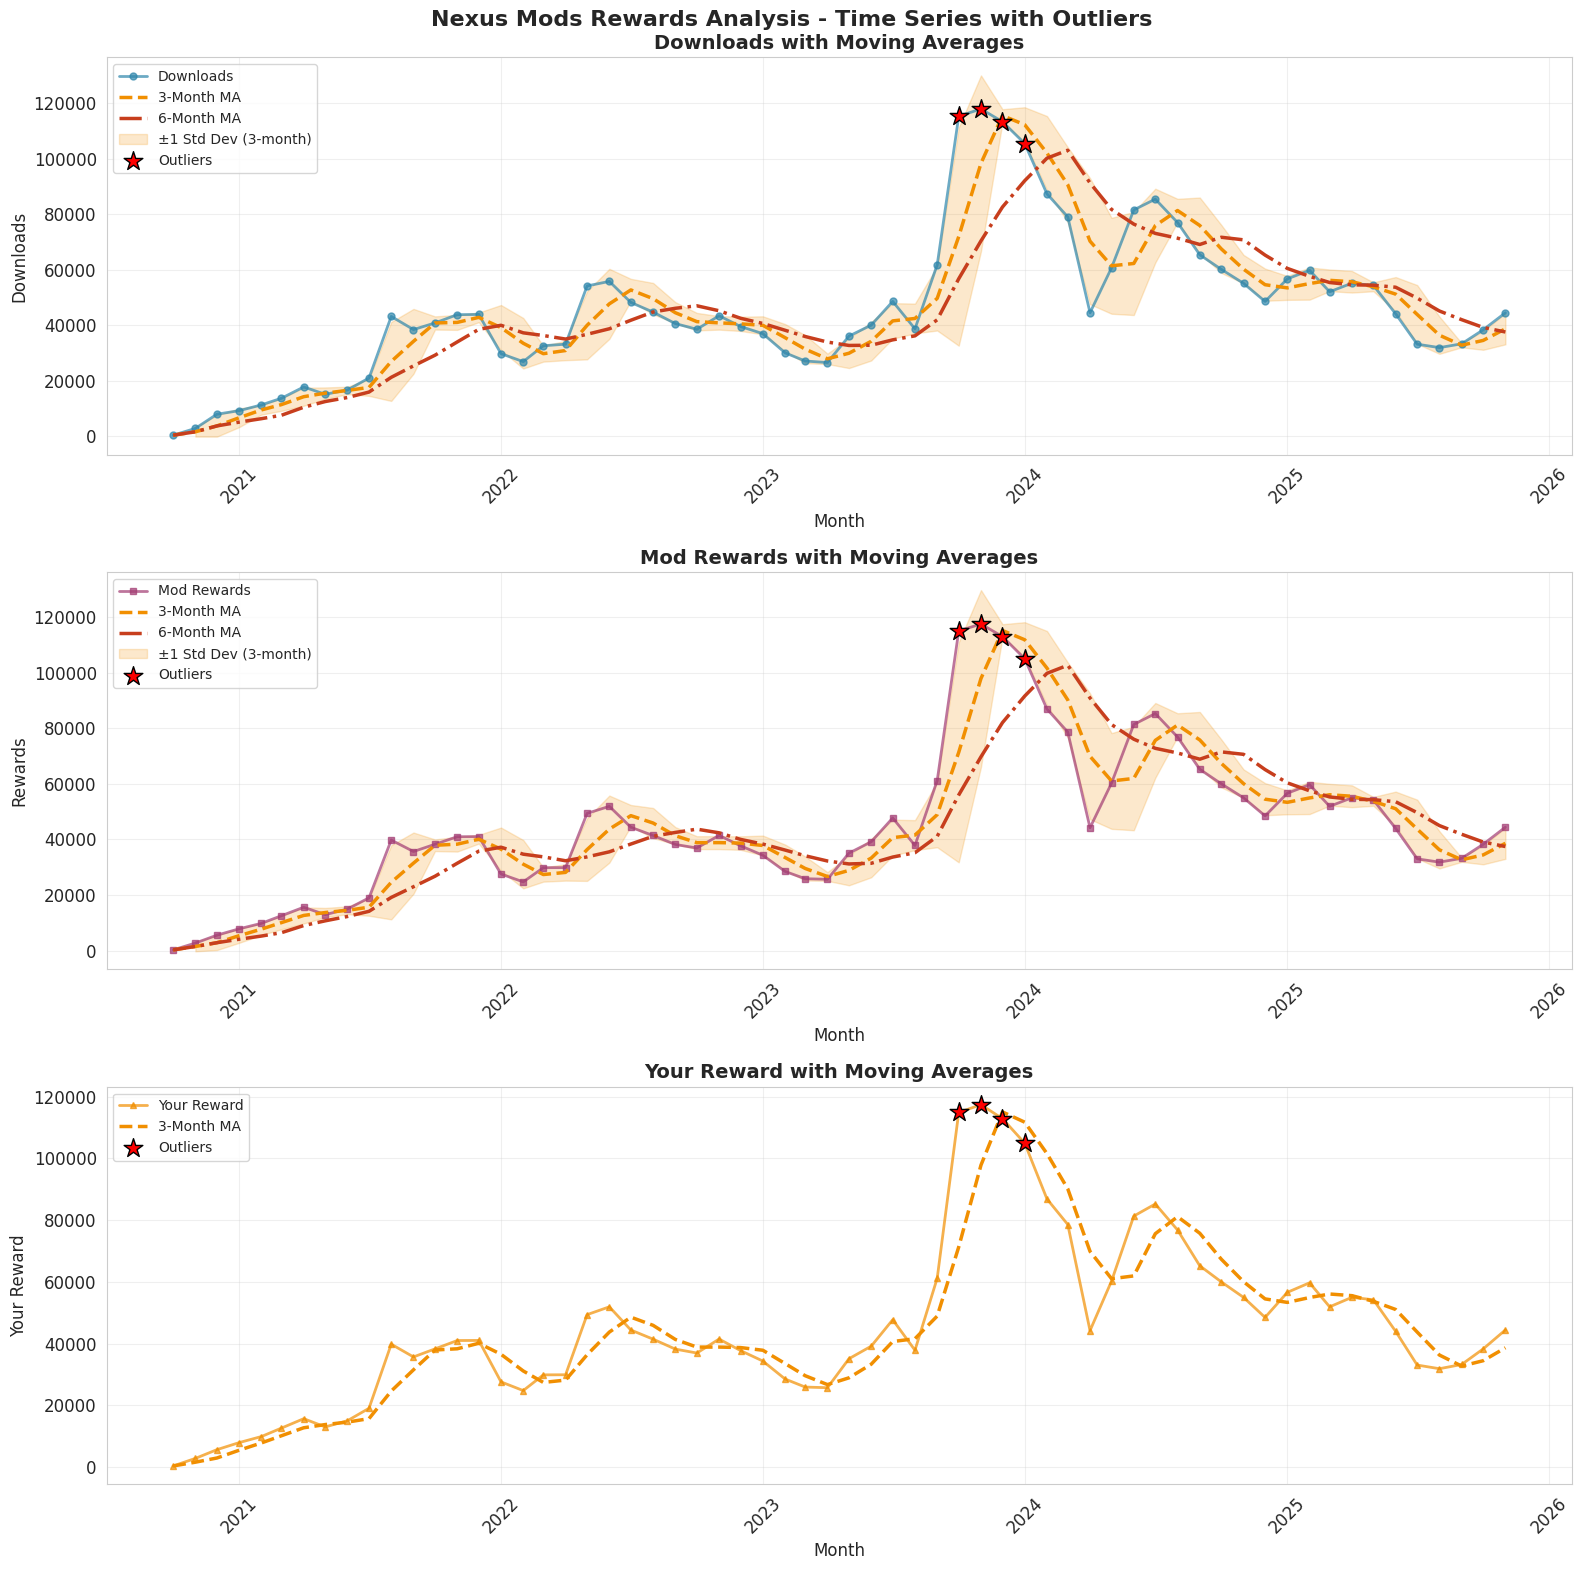


Visualization saved to: analysis_output/moving_averages_with_outliers.png


In [17]:
# Create time series plots with outliers highlighted
fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle('Nexus Mods Rewards Analysis - Time Series with Outliers', 
             fontsize=16, fontweight='bold')

# Plot 1: Downloads with moving averages and outliers
ax1 = axes[0]
ax1.plot(df.index, df['Downloads'], marker='o', linewidth=2, 
         markersize=5, label='Downloads', color=COLOR_DOWNLOADS, alpha=0.7)
ax1.plot(df.index, df['Downloads MA_3'], linewidth=2.5, 
         label=f'{MA_WINDOW_SHORT}-Month MA', color=COLOR_MA_SHORT, linestyle='--')
ax1.plot(df.index, df['Downloads MA_6'], linewidth=2.5, 
         label=f'{MA_WINDOW_LONG}-Month MA', color=COLOR_MA_LONG, linestyle='-.')
ax1.fill_between(df.index, df['Downloads MA_3'] - df['Downloads Std_3'], 
                  df['Downloads MA_3'] + df['Downloads Std_3'], 
                  alpha=0.2, color=COLOR_MA_SHORT, label='±1 Std Dev (3-month)')

# Highlight outliers
if df['Downloads Outlier'].any():
    outlier_dates = df.index[df['Downloads Outlier']]
    outlier_values = df.loc[df['Downloads Outlier'], 'Downloads']
    ax1.scatter(outlier_dates, outlier_values, s=200, 
              color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')

ax1.set_title('Downloads with Moving Averages', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Downloads', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards with moving averages and outliers
ax2 = axes[1]
ax2.plot(df.index, df['Mod Rewards'], marker='s', linewidth=2, 
         markersize=5, label='Mod Rewards', color=COLOR_REWARDS, alpha=0.7)
ax2.plot(df.index, df['Rewards MA_3'], linewidth=2.5, 
         label=f'{MA_WINDOW_SHORT}-Month MA', color=COLOR_MA_SHORT, linestyle='--')
ax2.plot(df.index, df['Rewards MA_6'], linewidth=2.5, 
         label=f'{MA_WINDOW_LONG}-Month MA', color=COLOR_MA_LONG, linestyle='-.')
ax2.fill_between(df.index, df['Rewards MA_3'] - df['Rewards Std_3'], 
                  df['Rewards MA_3'] + df['Rewards Std_3'], 
                  alpha=0.2, color=COLOR_MA_SHORT, label='±1 Std Dev (3-month)')

# Highlight outliers
if df['Rewards Outlier'].any():
    outlier_dates = df.index[df['Rewards Outlier']]
    outlier_values = df.loc[df['Rewards Outlier'], 'Mod Rewards']
    ax2.scatter(outlier_dates, outlier_values, s=200, 
              color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')

ax2.set_title('Mod Rewards with Moving Averages', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Rewards', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Your Reward with moving averages and outliers
ax3 = axes[2]
ax3.plot(df.index, df['Your Reward'], marker='^', linewidth=2, 
         markersize=5, label='Your Reward', color=COLOR_YOUR_REWARD, alpha=0.7)
ax3.plot(df.index, df['YourReward MA_3'], linewidth=2.5, 
         label=f'{MA_WINDOW_SHORT}-Month MA', color=COLOR_MA_SHORT, linestyle='--')

# Highlight outliers
if df['YourReward Outlier'].any():
    outlier_dates = df.index[df['YourReward Outlier']]
    outlier_values = df.loc[df['YourReward Outlier'], 'Your Reward']
    ax3.scatter(outlier_dates, outlier_values, s=200, 
              color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')

ax3.set_title('Your Reward with Moving Averages', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Your Reward', fontsize=12)
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/moving_averages_with_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/moving_averages_with_outliers.png")

## 11. Forecasting Visualization

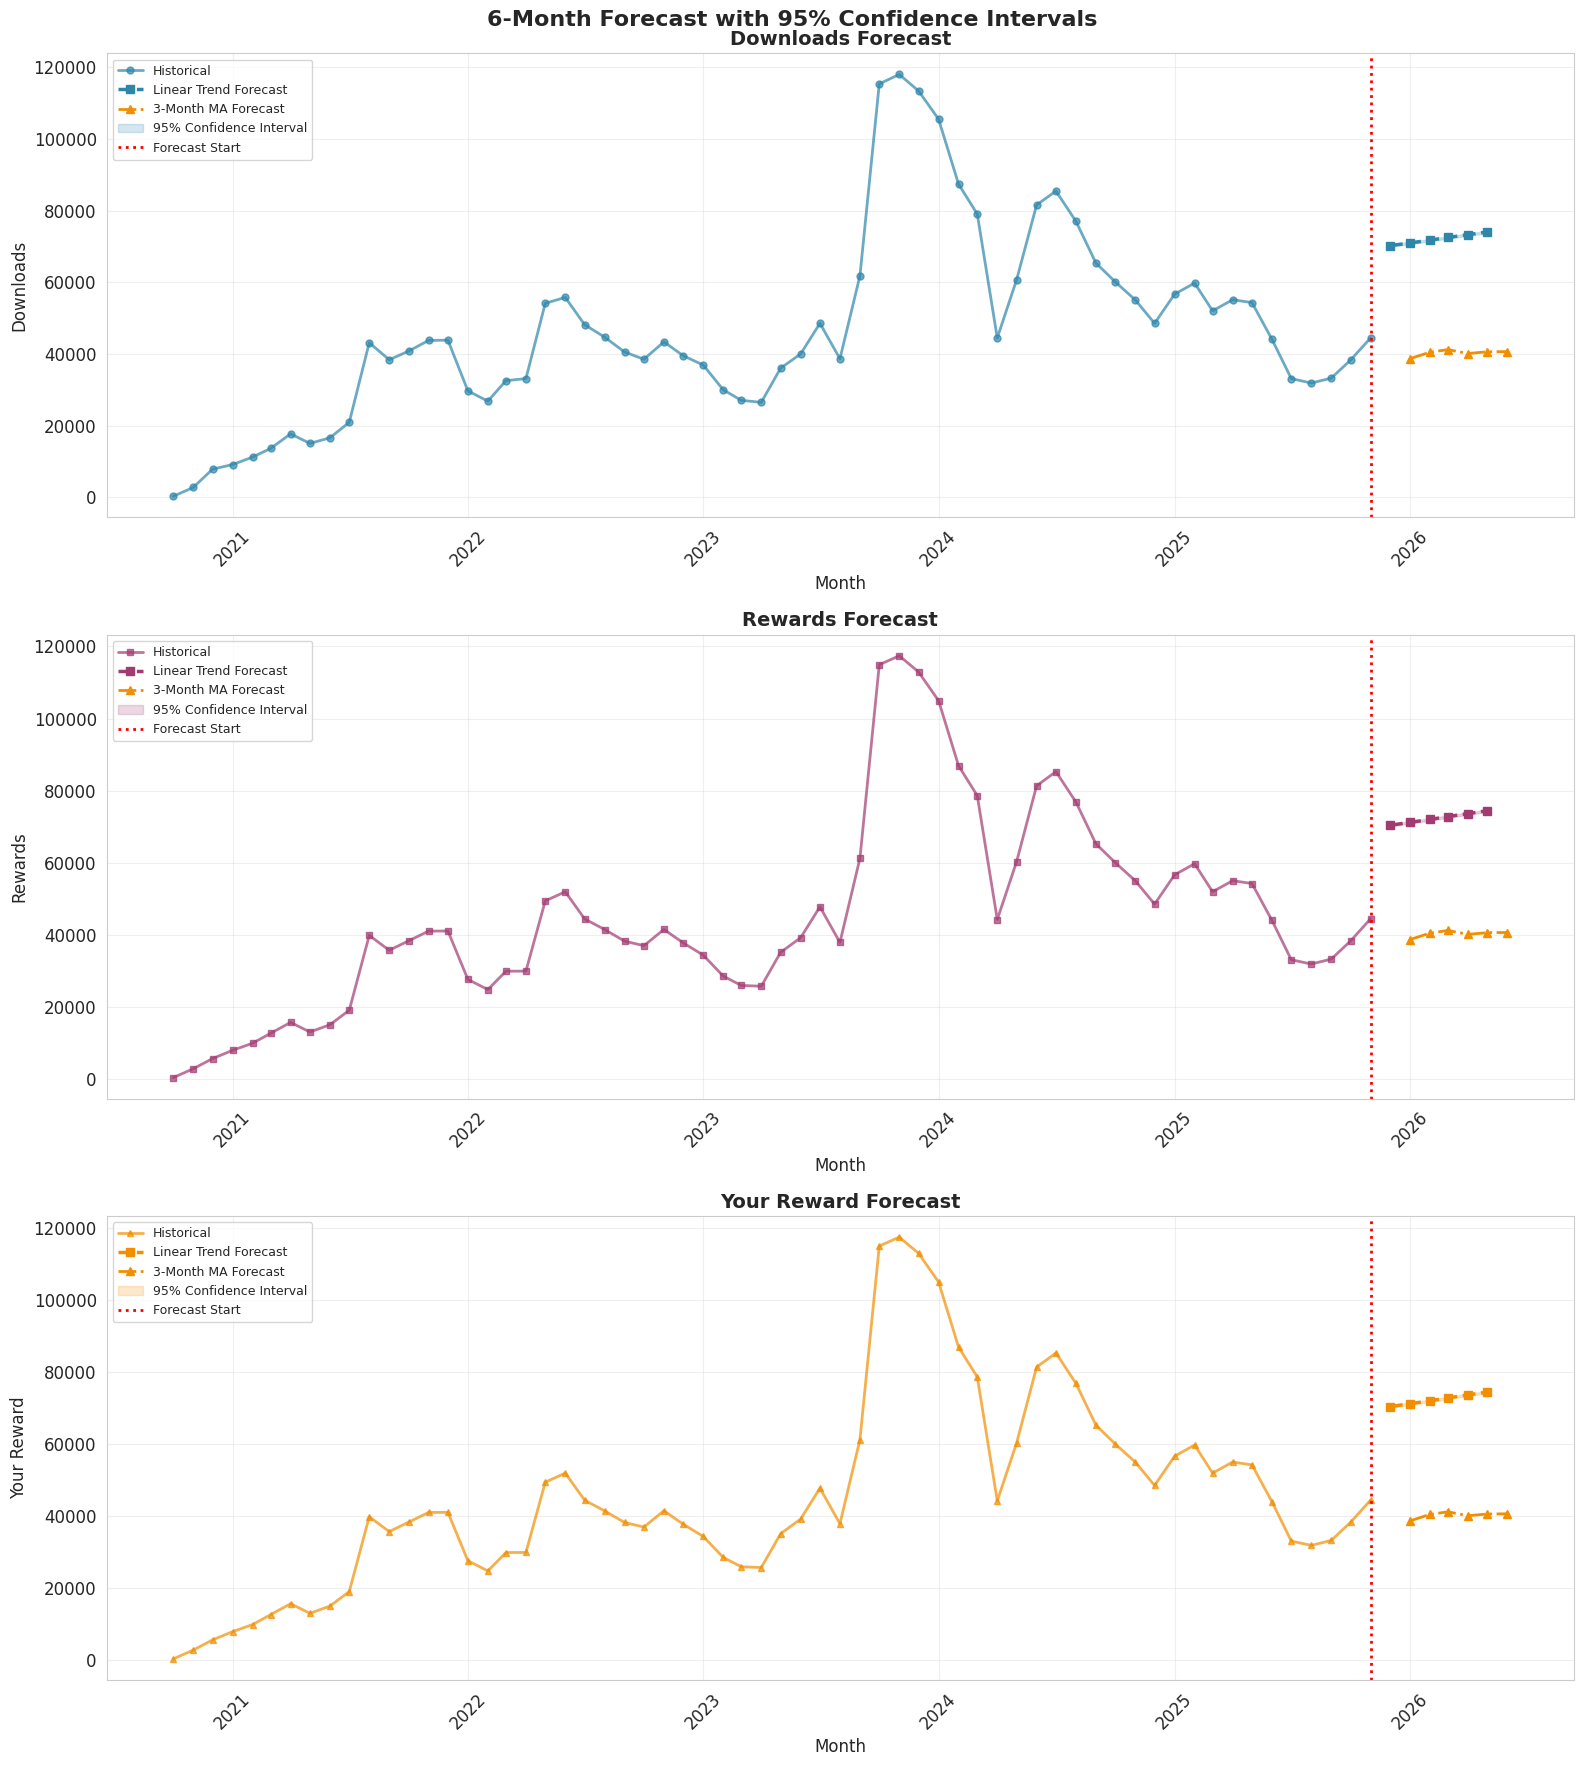


Visualization saved to: analysis_output/forecast_analysis.png


In [18]:
# Create forecast plots
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle(f'{FORECAST_PERIODS}-Month Forecast with 95% Confidence Intervals', 
             fontsize=16, fontweight='bold')

# Plot 1: Downloads forecast
ax1 = axes[0]
ax1.plot(df.index, df['Downloads'], marker='o', 
         linewidth=2, markersize=5, label='Historical', color=COLOR_DOWNLOADS, alpha=0.7)
ax1.plot(dl_forecast_dates, dl_forecast_values, marker='s', 
         linewidth=2.5, markersize=6, label='Linear Trend Forecast', 
         color=COLOR_DOWNLOADS, linestyle='--')
ax1.plot(dl_ma_dates, dl_ma_forecast, marker='^', 
         linewidth=2, markersize=6, label=f'{MA_WINDOW_SHORT}-Month MA Forecast', 
         color=COLOR_MA_SHORT, linestyle='-.')
ax1.fill_between(dl_forecast_dates, dl_confidence['lower'], 
                  dl_confidence['upper'], alpha=0.2, color=COLOR_DOWNLOADS, 
                  label='95% Confidence Interval')
ax1.axvline(x=df.index[-1], color='red', linestyle=':', 
             linewidth=2, label='Forecast Start')
ax1.set_title('Downloads Forecast', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Downloads', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards forecast
ax2 = axes[1]
ax2.plot(df.index, df['Mod Rewards'], marker='s', 
         linewidth=2, markersize=5, label='Historical', color=COLOR_REWARDS, alpha=0.7)
ax2.plot(rw_forecast_dates, rw_forecast_values, marker='s', 
         linewidth=2.5, markersize=6, label='Linear Trend Forecast', 
         color=COLOR_REWARDS, linestyle='--')
ax2.plot(rw_ma_dates, rw_ma_forecast, marker='^', 
         linewidth=2, markersize=6, label=f'{MA_WINDOW_SHORT}-Month MA Forecast', 
         color=COLOR_MA_SHORT, linestyle='-.')
ax2.fill_between(rw_forecast_dates, rw_confidence['lower'], 
                  rw_confidence['upper'], alpha=0.2, color=COLOR_REWARDS, 
                  label='95% Confidence Interval')
ax2.axvline(x=df.index[-1], color='red', linestyle=':', 
             linewidth=2, label='Forecast Start')
ax2.set_title('Rewards Forecast', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Rewards', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Your Reward forecast
ax3 = axes[2]
ax3.plot(df.index, df['Your Reward'], marker='^', 
         linewidth=2, markersize=5, label='Historical', color=COLOR_YOUR_REWARD, alpha=0.7)
ax3.plot(yr_forecast_dates, yr_forecast_values, marker='s', 
         linewidth=2.5, markersize=6, label='Linear Trend Forecast', 
         color=COLOR_YOUR_REWARD, linestyle='--')
ax3.plot(yr_ma_dates, yr_ma_forecast, marker='^', 
         linewidth=2, markersize=6, label=f'{MA_WINDOW_SHORT}-Month MA Forecast', 
         color=COLOR_MA_SHORT, linestyle='-.')
ax3.fill_between(yr_forecast_dates, yr_confidence['lower'], 
                  yr_confidence['upper'], alpha=0.2, color=COLOR_YOUR_REWARD, 
                  label='95% Confidence Interval')
ax3.axvline(x=df.index[-1], color='red', linestyle=':', 
             linewidth=2, label='Forecast Start')
ax3.set_title('Your Reward Forecast', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Your Reward', fontsize=12)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/forecast_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/forecast_analysis.png")

## 12. Growth Rate Analysis

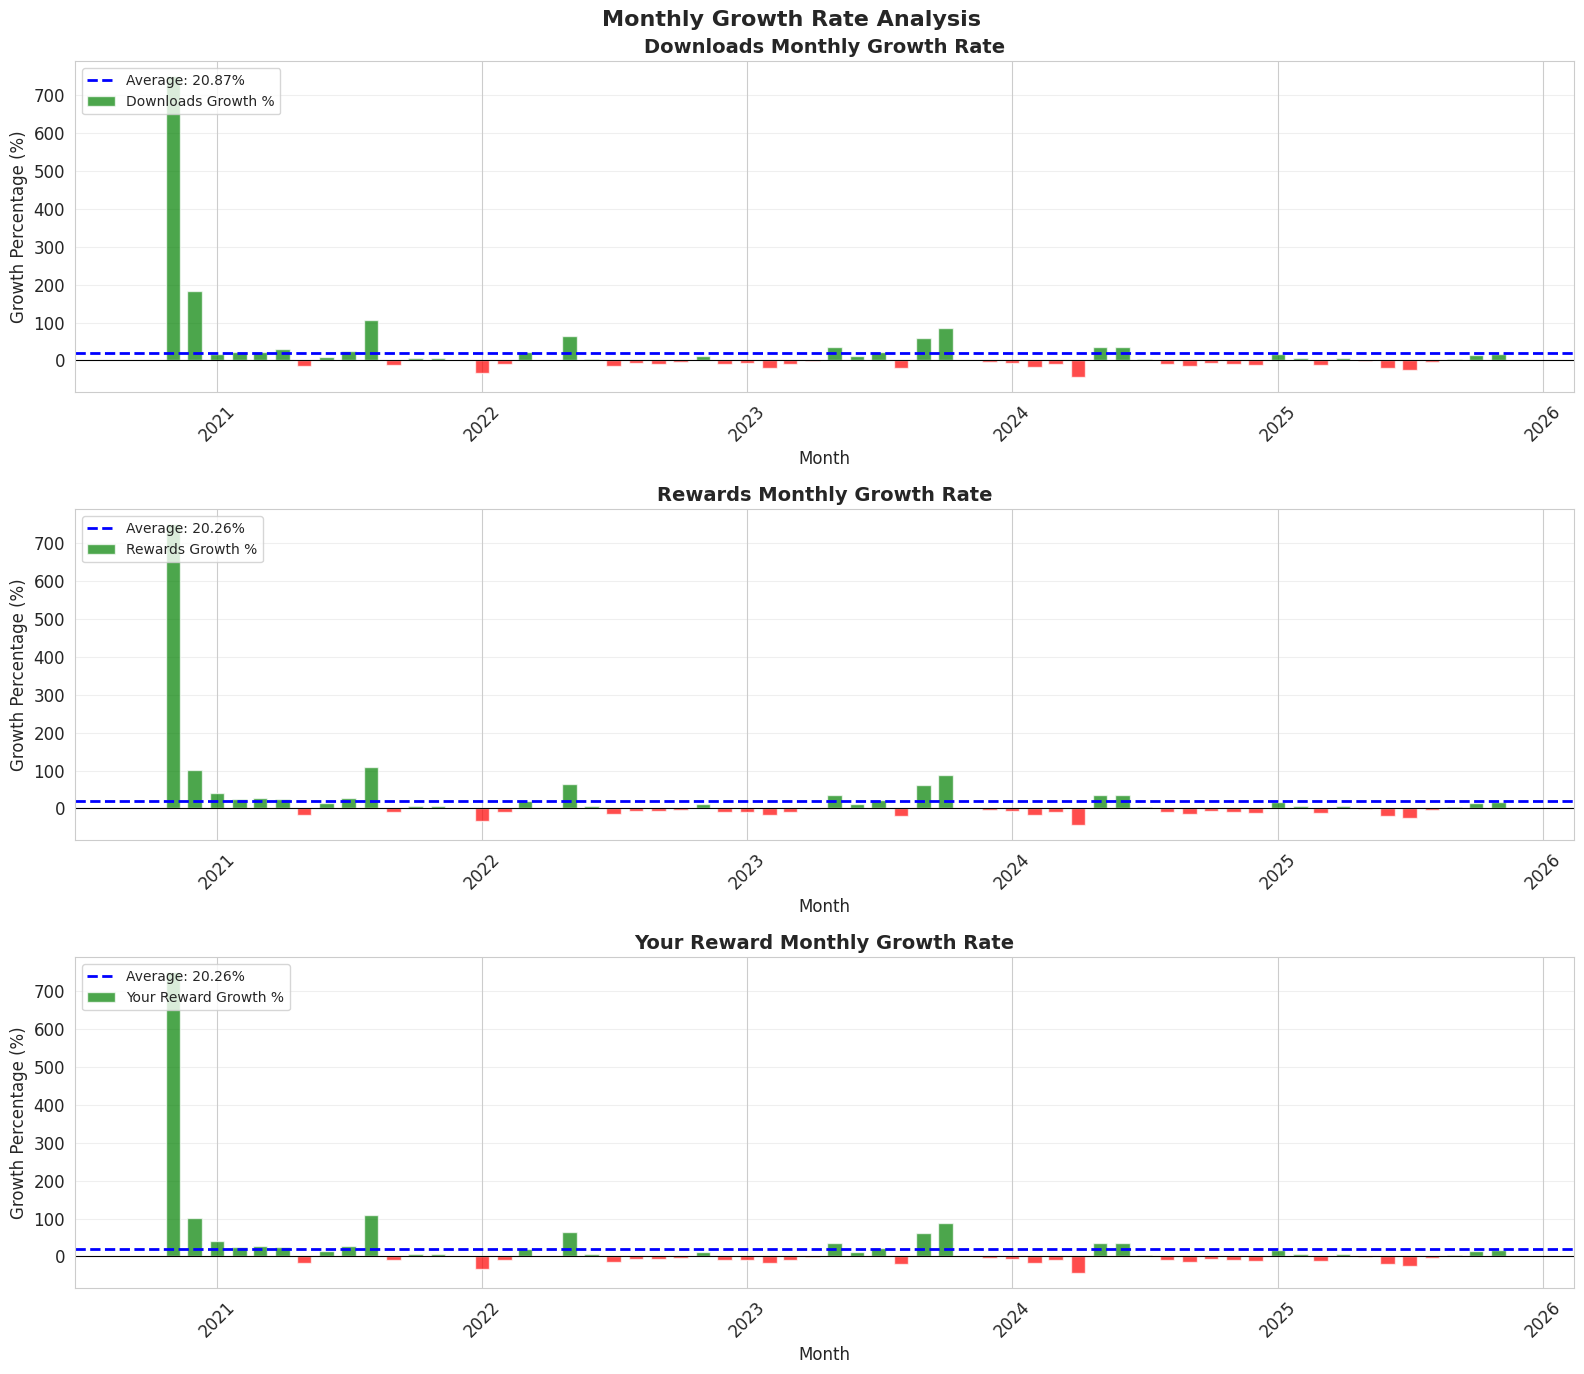


Visualization saved to: analysis_output/growth_rates.png


In [19]:
# Create growth rate visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Monthly Growth Rate Analysis', fontsize=16, fontweight='bold')

# Plot 1: Downloads growth rates over time
ax1 = axes[0]
colors = [COLOR_POSITIVE if x >= 0 else COLOR_NEGATIVE for x in df['Downloads Growth %'].fillna(0)]
ax1.bar(df.index, df['Downloads Growth %'].fillna(0), width=20, 
        alpha=0.7, label='Downloads Growth %', color=colors)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.axhline(y=df['Downloads Growth %'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Average: {df["Downloads Growth %"].mean():.2f}%')
ax1.set_title('Downloads Monthly Growth Rate', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Growth Percentage (%)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards growth rates
ax2 = axes[1]
colors = [COLOR_POSITIVE if x >= 0 else COLOR_NEGATIVE for x in df['Rewards Growth %'].fillna(0)]
ax2.bar(df.index, df['Rewards Growth %'].fillna(0), width=20, 
        alpha=0.7, label='Rewards Growth %', color=colors)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.axhline(y=df['Rewards Growth %'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Average: {df["Rewards Growth %"].mean():.2f}%')
ax2.set_title('Rewards Monthly Growth Rate', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Growth Percentage (%)', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Your Reward growth rates
ax3 = axes[2]
colors = [COLOR_POSITIVE if x >= 0 else COLOR_NEGATIVE for x in df['YourReward Growth %'].fillna(0)]
ax3.bar(df.index, df['YourReward Growth %'].fillna(0), width=20, 
        alpha=0.7, label='Your Reward Growth %', color=colors)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=df['YourReward Growth %'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Average: {df["YourReward Growth %"].mean():.2f}%')
ax3.set_title('Your Reward Monthly Growth Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Growth Percentage (%)', fontsize=12)
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/growth_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/growth_rates.png")

## 13. Correlation and Scatter Analysis

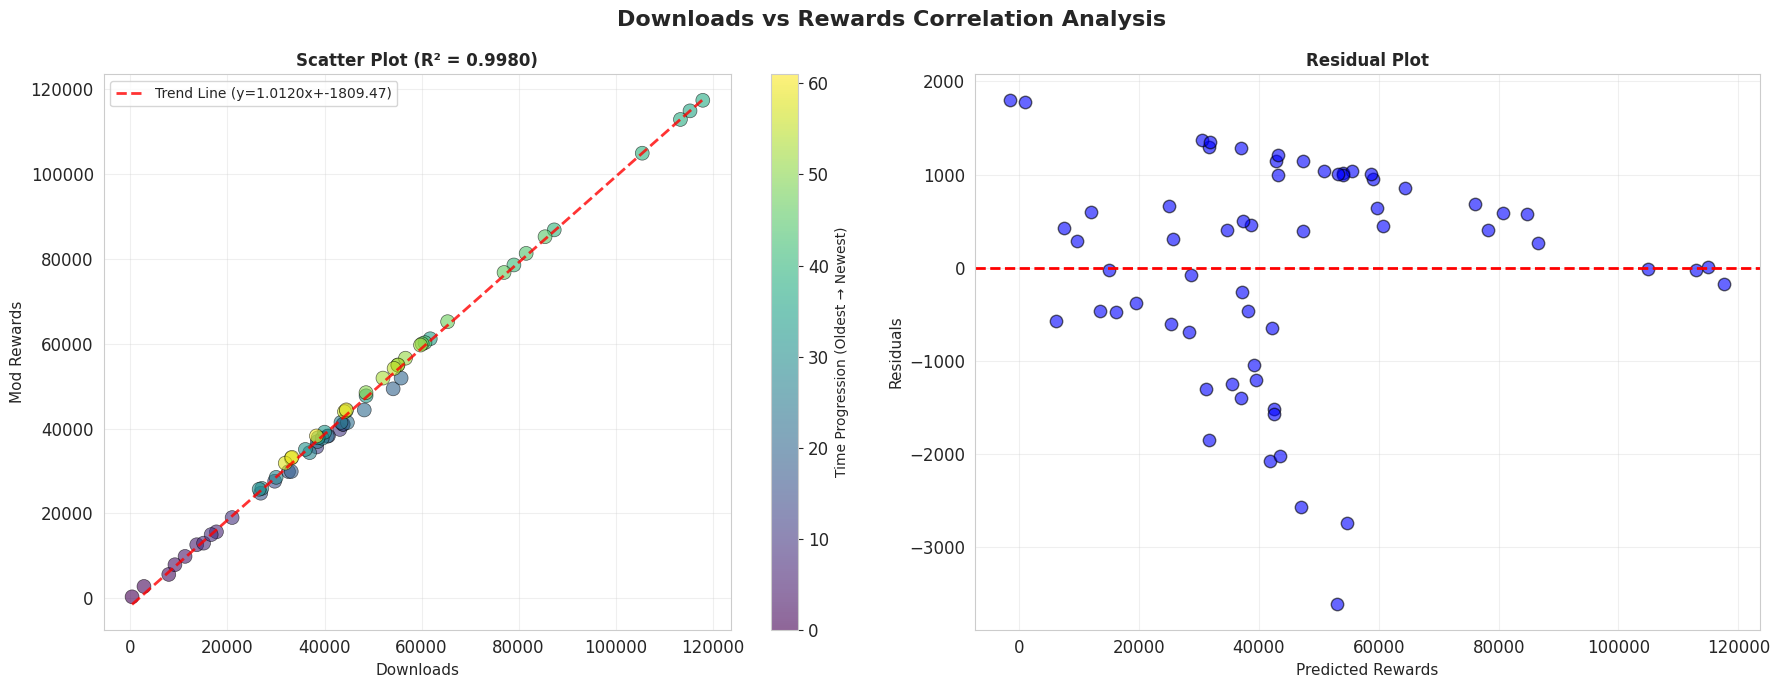


Visualization saved to: analysis_output/correlation_analysis.png


In [20]:
# Create scatter plot with detailed analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Downloads vs Rewards Correlation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Scatter plot with trend line
ax1 = axes[0]
scatter = ax1.scatter(df['Downloads'], df['Mod Rewards'], 
                      c=range(len(df)), cmap='viridis', s=100, alpha=0.6, 
                      edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(df['Downloads'], df['Mod Rewards'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Downloads'].min(), df['Downloads'].max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, 
         label=f'Trend Line (y={z[0]:.4f}x+{z[1]:.2f})')

# Add R-squared
y_pred = p(df['Downloads'])
y_actual = df['Mod Rewards']
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

ax1.set_title(f'Scatter Plot (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Downloads', fontsize=11)
ax1.set_ylabel('Mod Rewards', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add colorbar to show time progression
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Time Progression (Oldest → Newest)', fontsize=10)

# Plot 2: Residual plot
ax2 = axes[1]
residuals = y_actual - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, color='blue', s=80, edgecolors='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Rewards', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/correlation_analysis.png")

## 14. Reward Efficiency Analysis

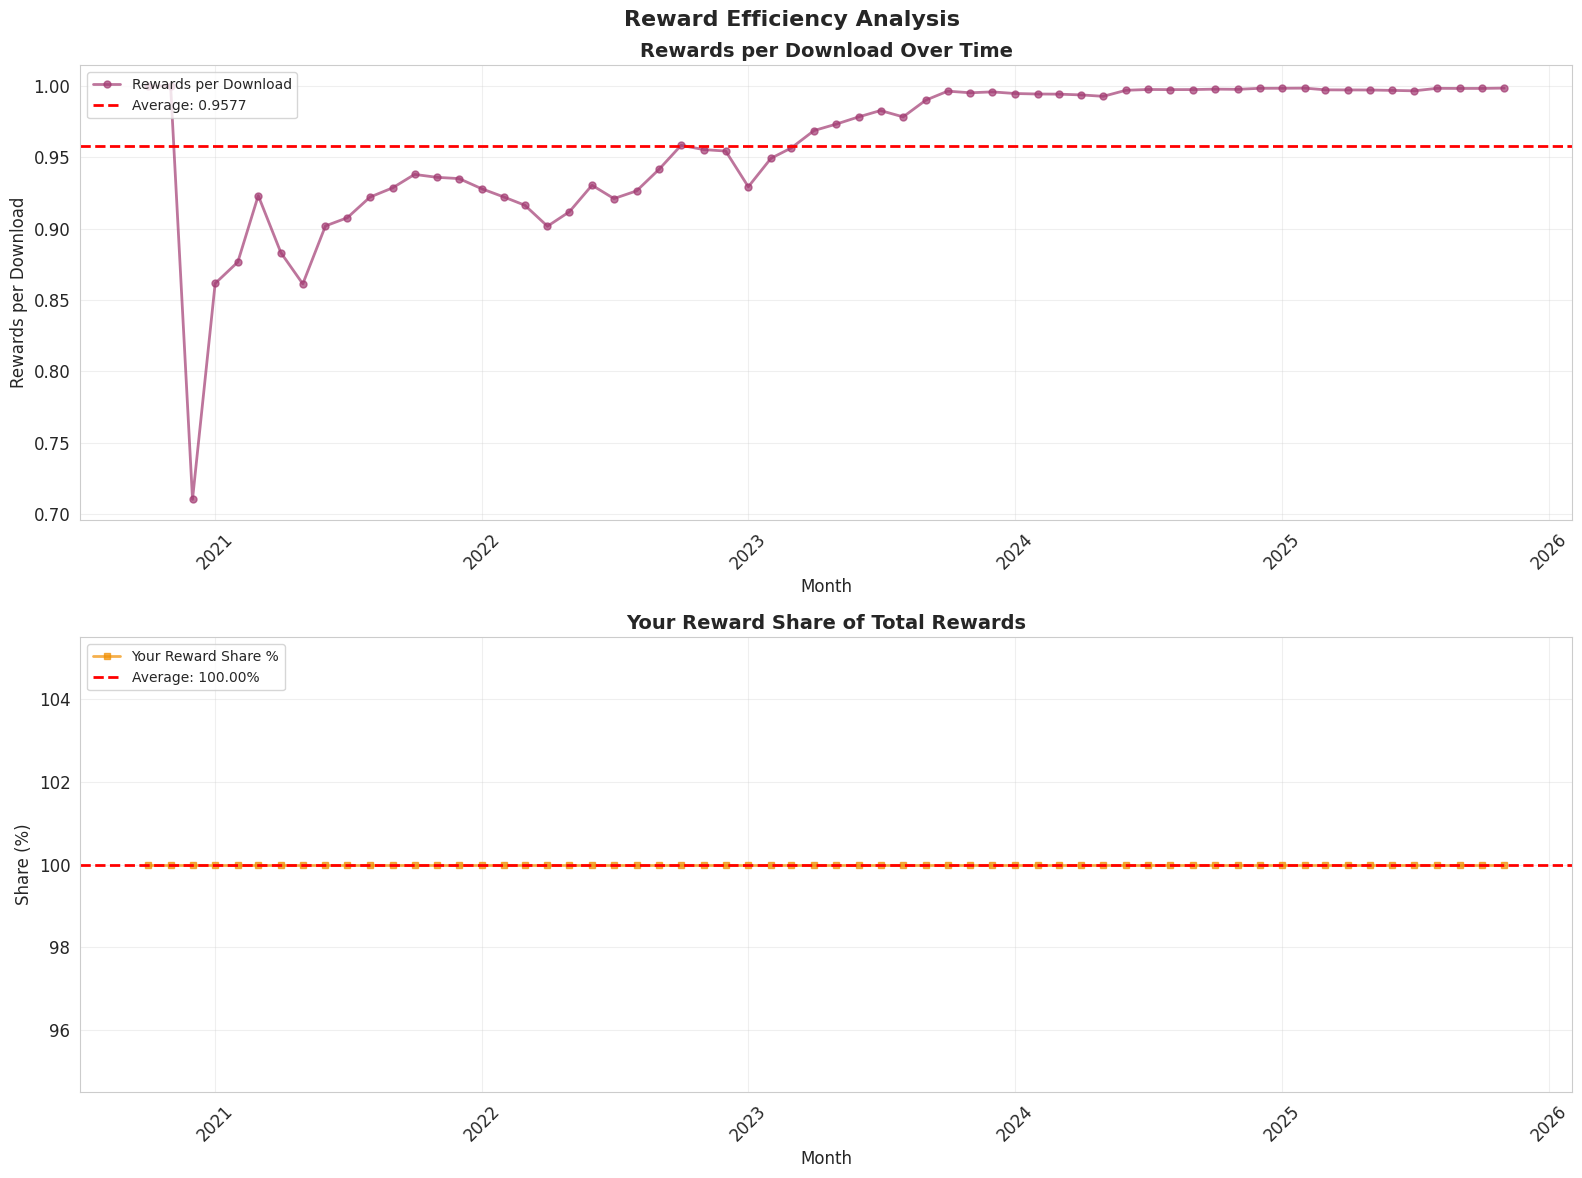


Visualization saved to: analysis_output/reward_efficiency.png


In [21]:
# Create reward efficiency visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Reward Efficiency Analysis', fontsize=16, fontweight='bold')

# Plot 1: Rewards per Download over time
ax1 = axes[0]
ax1.plot(df.index, df['Rewards per Download'], marker='o', linewidth=2, 
         markersize=5, label='Rewards per Download', color=COLOR_REWARDS, alpha=0.7)
ax1.axhline(y=df['Rewards per Download'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Average: {df["Rewards per Download"].mean():.4f}')
ax1.set_title('Rewards per Download Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Rewards per Download', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Your Reward Share percentage
ax2 = axes[1]
ax2.plot(df.index, df['YourReward Share %'], marker='s', linewidth=2, 
         markersize=5, label='Your Reward Share %', color=COLOR_YOUR_REWARD, alpha=0.7)
ax2.axhline(y=df['YourReward Share %'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Average: {df["YourReward Share %"].mean():.2f}%')
ax2.set_title('Your Reward Share of Total Rewards', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Share (%)', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/reward_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/reward_efficiency.png")

## 15. Rolling Correlation Analysis

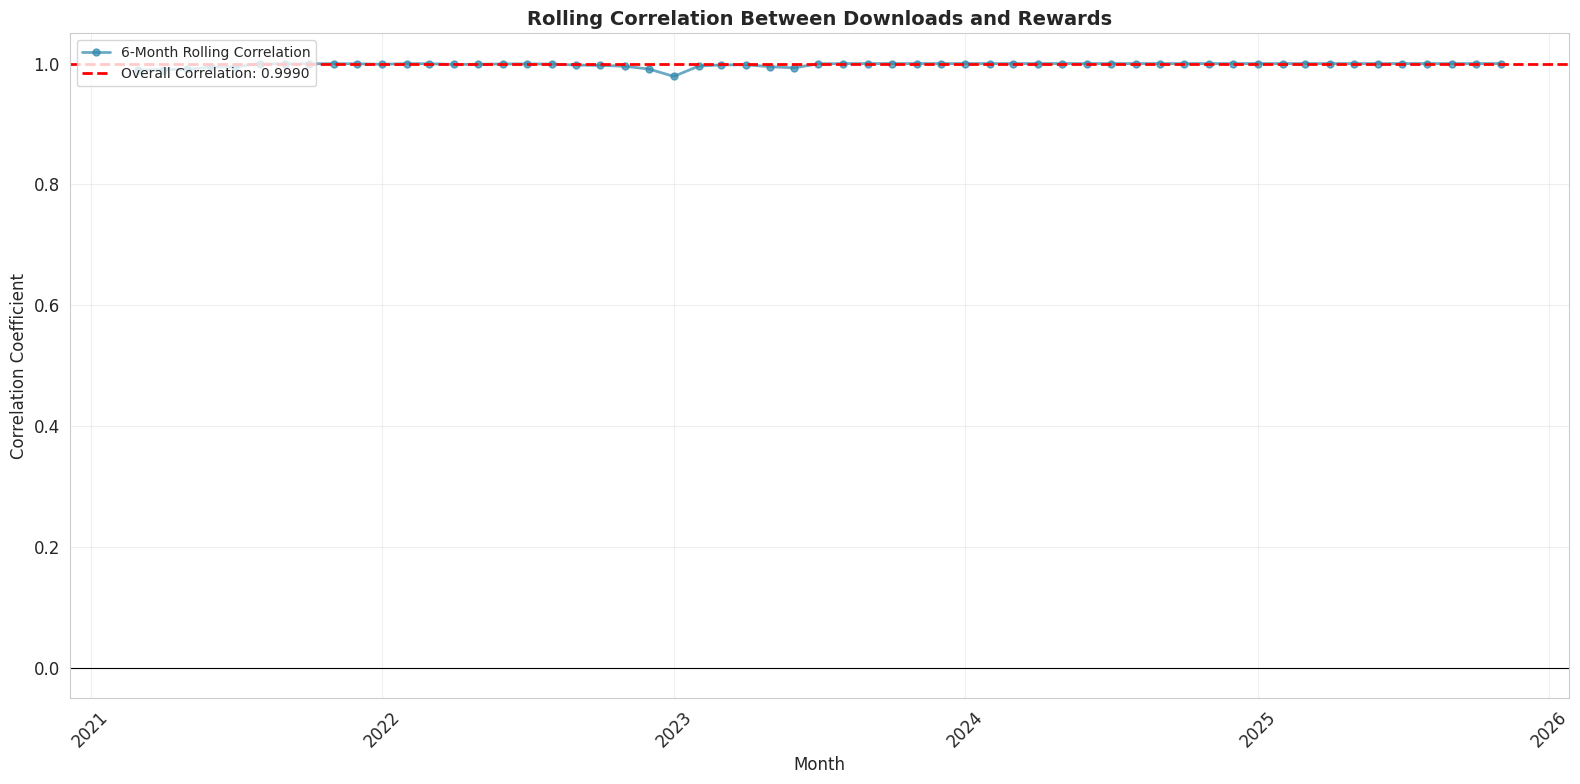


Visualization saved to: analysis_output/rolling_correlation.png


In [22]:
# Create rolling correlation visualization
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df.index, df['Rolling Correlation'], marker='o', linewidth=2, 
        markersize=5, label=f'{MA_WINDOW_LONG}-Month Rolling Correlation', 
        color=COLOR_DOWNLOADS, alpha=0.7)
ax.axhline(y=correlation, color='red', linestyle='--', 
           linewidth=2, label=f'Overall Correlation: {correlation:.4f}')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Rolling Correlation Between Downloads and Rewards', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/rolling_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/rolling_correlation.png")

## 16. Seasonal Patterns Visualization

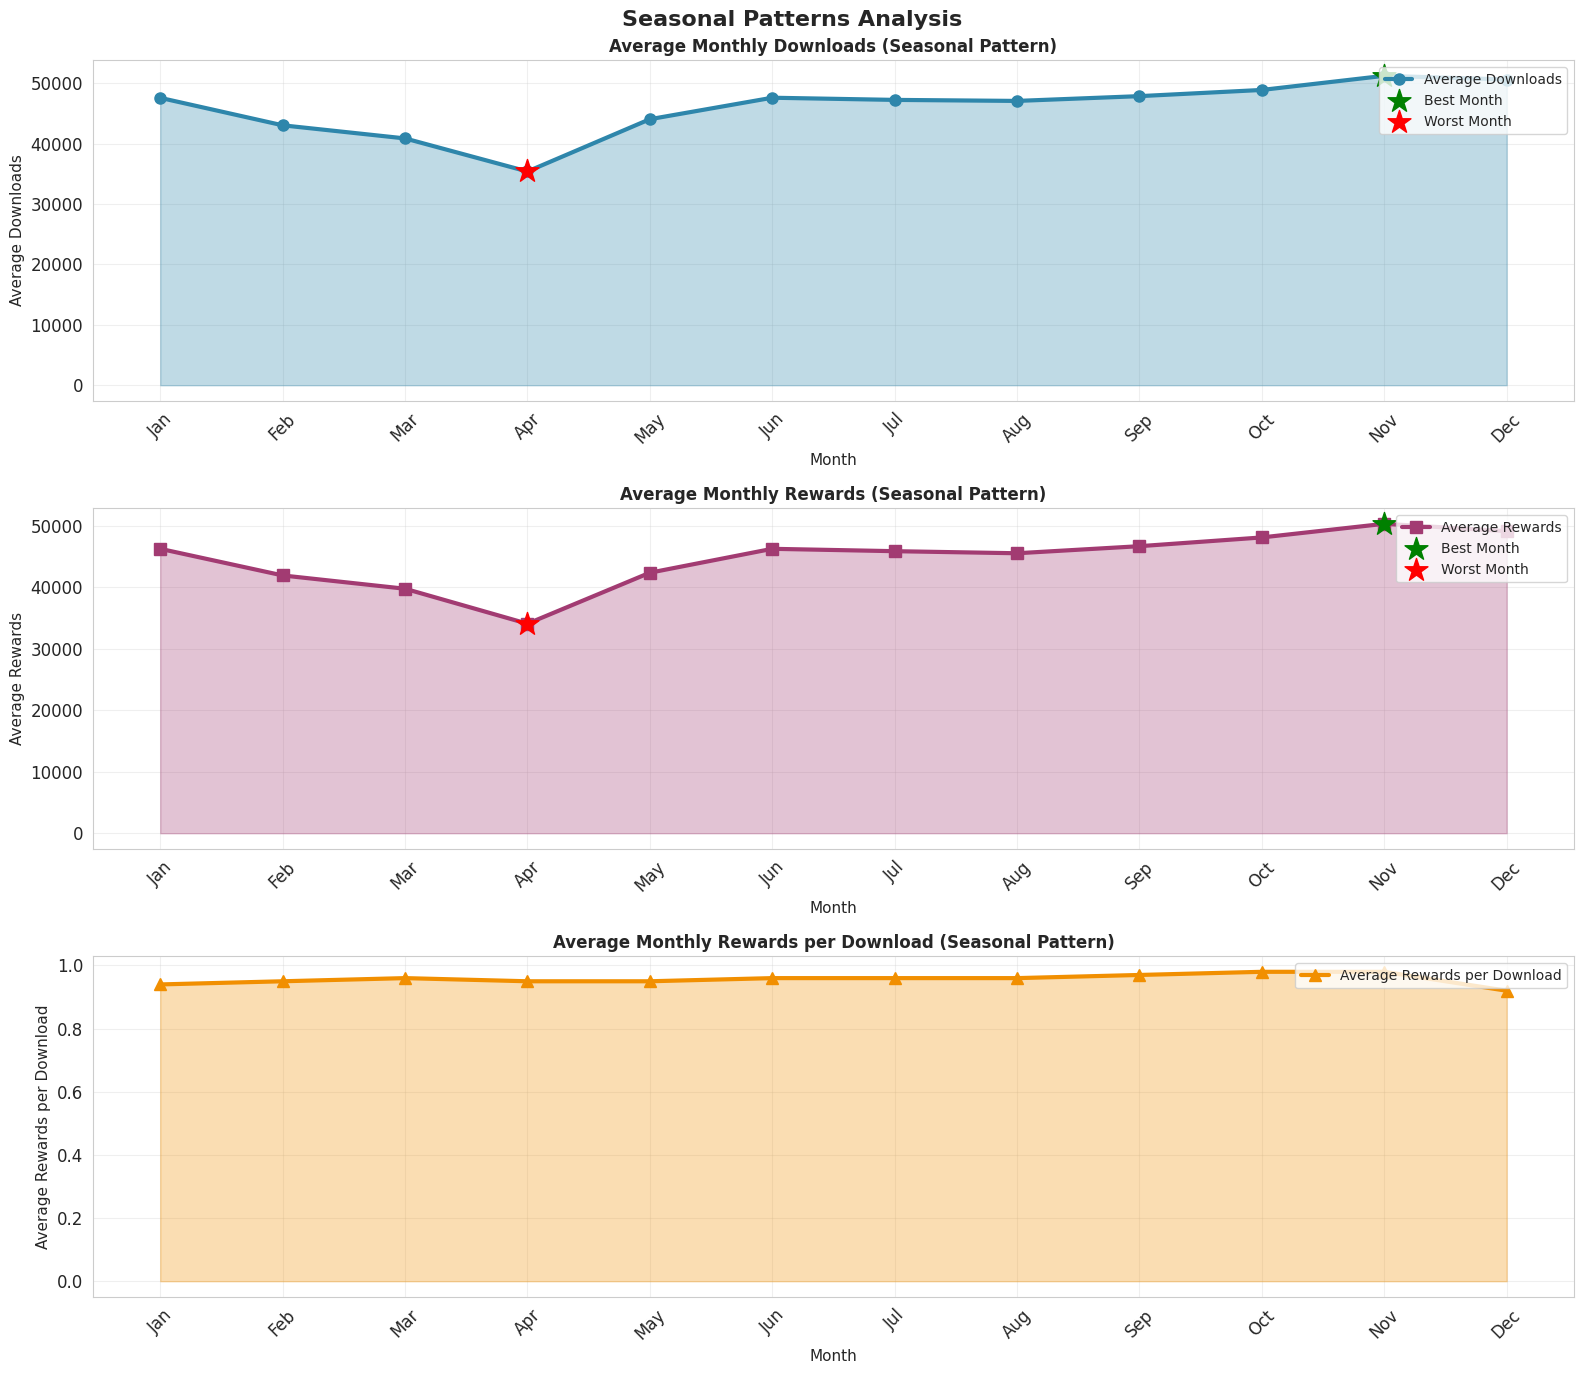


Visualization saved to: analysis_output/seasonal_patterns.png


In [23]:
# Monthly average across all years (seasonal patterns)
monthly_avg = df.groupby('Month_Num').agg({
    'Downloads': 'mean',
    'Mod Rewards': 'mean',
    'Your Reward': 'mean',
    'Rewards per Download': 'mean'
}).round(2)

# Add month names
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg['Month_Name'] = month_names

# Create seasonal patterns visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Seasonal Patterns Analysis', fontsize=16, fontweight='bold')

# Plot 1: Monthly averages across all years - Downloads
ax1 = axes[0]
x = range(1, 13)
ax1.plot(x, monthly_avg['Downloads'], marker='o', linewidth=3, 
         markersize=8, label='Average Downloads', color=COLOR_DOWNLOADS, 
         linestyle='-')
ax1.fill_between(x, monthly_avg['Downloads'], alpha=0.3, color=COLOR_DOWNLOADS)
ax1.set_xticks(x)
ax1.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax1.set_title('Average Monthly Downloads (Seasonal Pattern)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Average Downloads', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Highlight best and worst months
best_idx = monthly_avg['Downloads'].idxmax()
worst_idx = monthly_avg['Downloads'].idxmin()
ax1.scatter([best_idx], [monthly_avg.loc[best_idx, 'Downloads']], 
            s=300, color='green', marker='*', label='Best Month', zorder=5)
ax1.scatter([worst_idx], [monthly_avg.loc[worst_idx, 'Downloads']], 
            s=300, color='red', marker='*', label='Worst Month', zorder=5)
ax1.legend(loc='upper right', fontsize=10)

# Plot 2: Monthly rewards averages
ax2 = axes[1]
ax2.plot(x, monthly_avg['Mod Rewards'], marker='s', linewidth=3, 
         markersize=8, label='Average Rewards', color=COLOR_REWARDS, 
         linestyle='-')
ax2.fill_between(x, monthly_avg['Mod Rewards'], alpha=0.3, color=COLOR_REWARDS)
ax2.set_xticks(x)
ax2.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax2.set_title('Average Monthly Rewards (Seasonal Pattern)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Average Rewards', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# Highlight best and worst months
best_idx = monthly_avg['Mod Rewards'].idxmax()
worst_idx = monthly_avg['Mod Rewards'].idxmin()
ax2.scatter([best_idx], [monthly_avg.loc[best_idx, 'Mod Rewards']], 
            s=300, color='green', marker='*', label='Best Month', zorder=5)
ax2.scatter([worst_idx], [monthly_avg.loc[worst_idx, 'Mod Rewards']], 
            s=300, color='red', marker='*', label='Worst Month', zorder=5)
ax2.legend(loc='upper right', fontsize=10)

# Plot 3: Monthly reward efficiency averages
ax3 = axes[2]
ax3.plot(x, monthly_avg['Rewards per Download'], marker='^', linewidth=3, 
         markersize=8, label='Average Rewards per Download', color=COLOR_YOUR_REWARD, 
         linestyle='-')
ax3.fill_between(x, monthly_avg['Rewards per Download'], alpha=0.3, color=COLOR_YOUR_REWARD)
ax3.set_xticks(x)
ax3.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax3.set_title('Average Monthly Rewards per Download (Seasonal Pattern)', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Average Rewards per Download', fontsize=11)
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/seasonal_patterns.png")

## 17. Year-over-Year Comparison

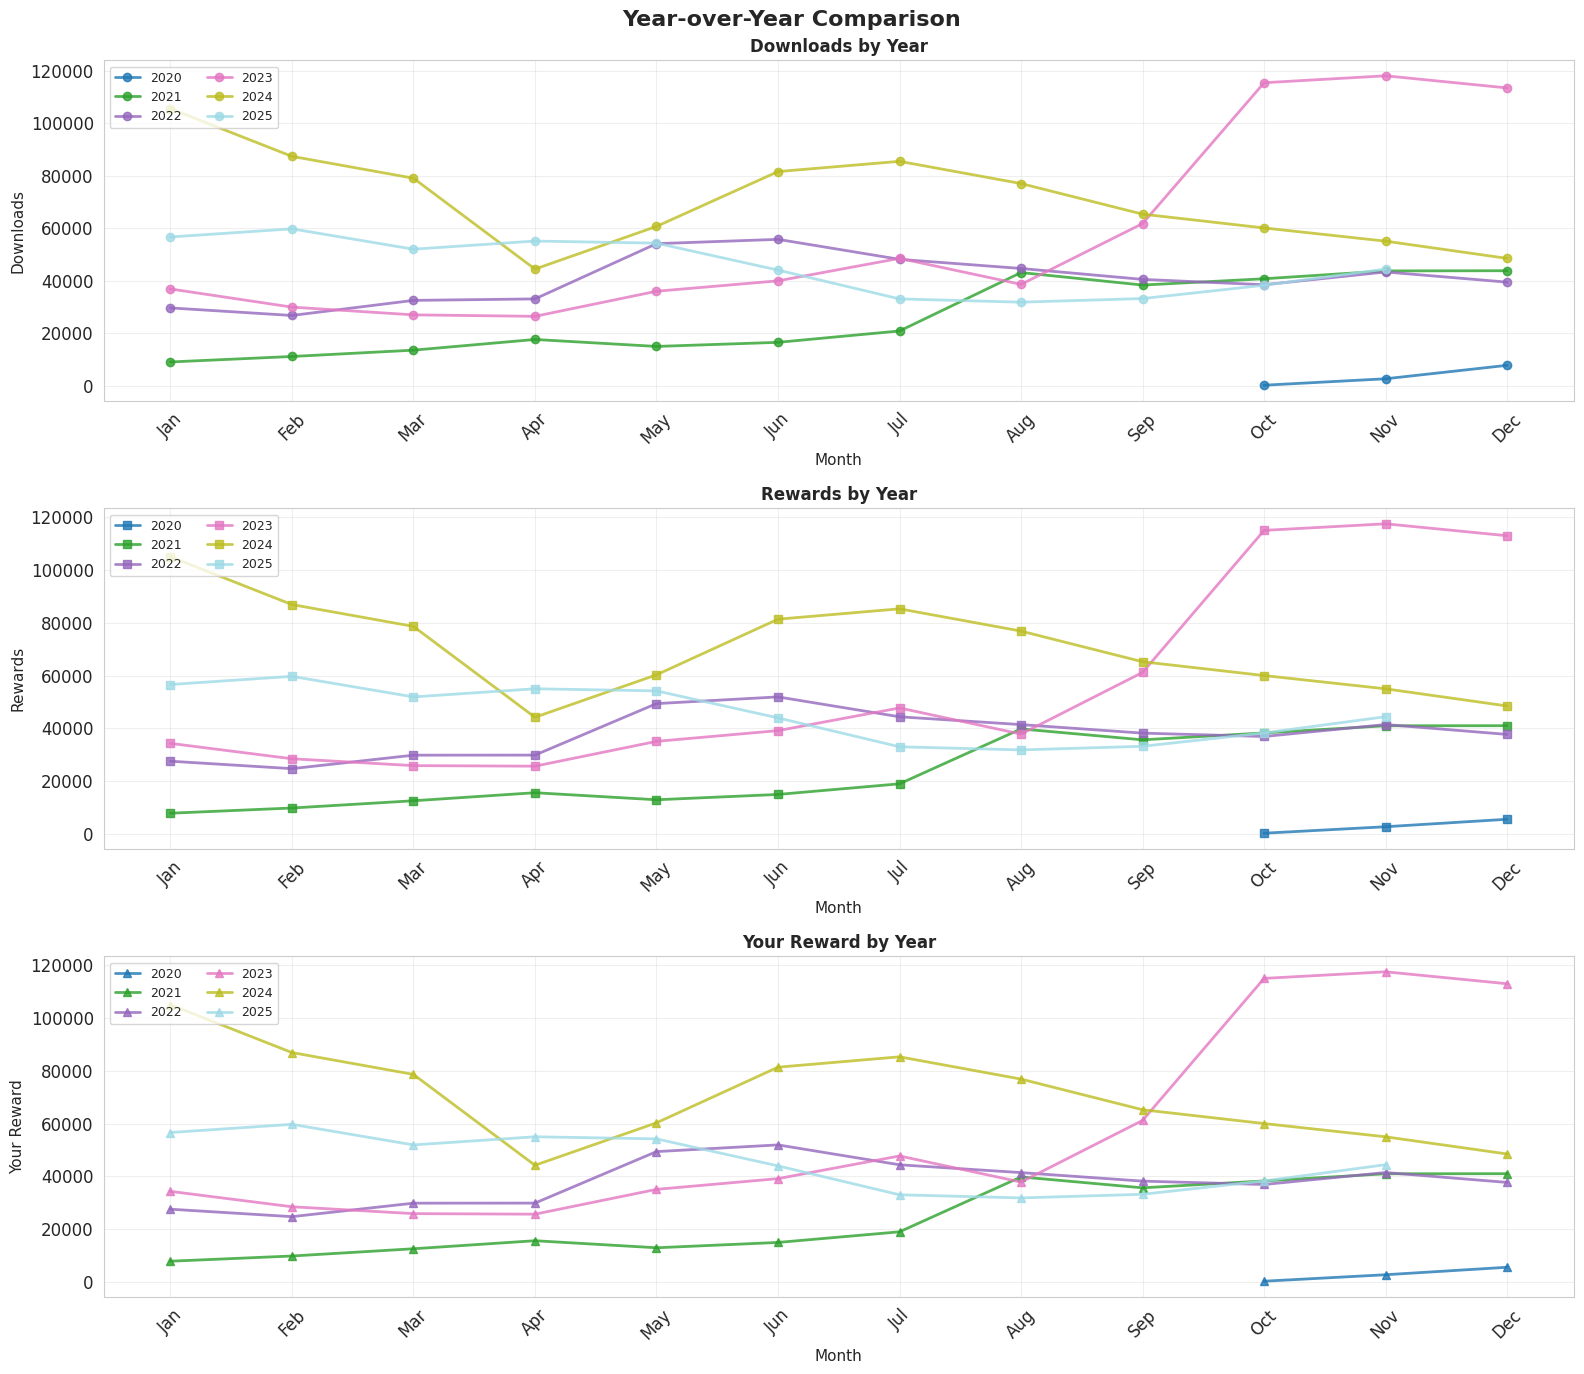


Visualization saved to: analysis_output/year_over_year.png


In [24]:
# Create year-over-year comparison
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Year-over-Year Comparison', fontsize=16, fontweight='bold')

# Get unique years
years = df['Year'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(years)))

# Plot 1: Downloads by year
ax1 = axes[0]
for i, year in enumerate(sorted(years)):
    year_data = df[df['Year'] == year]
    ax1.plot(year_data.index.month, year_data['Downloads'], 
             marker='o', linewidth=2, markersize=6, 
             label=f'{year}', color=colors[i], alpha=0.8)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax1.set_title('Downloads by Year', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Downloads', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

# Plot 2: Rewards by year
ax2 = axes[1]
for i, year in enumerate(sorted(years)):
    year_data = df[df['Year'] == year]
    ax2.plot(year_data.index.month, year_data['Mod Rewards'], 
             marker='s', linewidth=2, markersize=6, 
             label=f'{year}', color=colors[i], alpha=0.8)

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax2.set_title('Rewards by Year', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Rewards', fontsize=11)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

# Plot 3: Your Reward by year
ax3 = axes[2]
for i, year in enumerate(sorted(years)):
    year_data = df[df['Year'] == year]
    ax3.plot(year_data.index.month, year_data['Your Reward'], 
             marker='^', linewidth=2, markersize=6, 
             label=f'{year}', color=colors[i], alpha=0.8)

ax3.set_xticks(range(1, 13))
ax3.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax3.set_title('Your Reward by Year', fontsize=12, fontweight='bold')
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Your Reward', fontsize=11)
ax3.legend(loc='upper left', fontsize=9, ncol=2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/year_over_year.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/year_over_year.png")

## 18. Heatmap Visualization

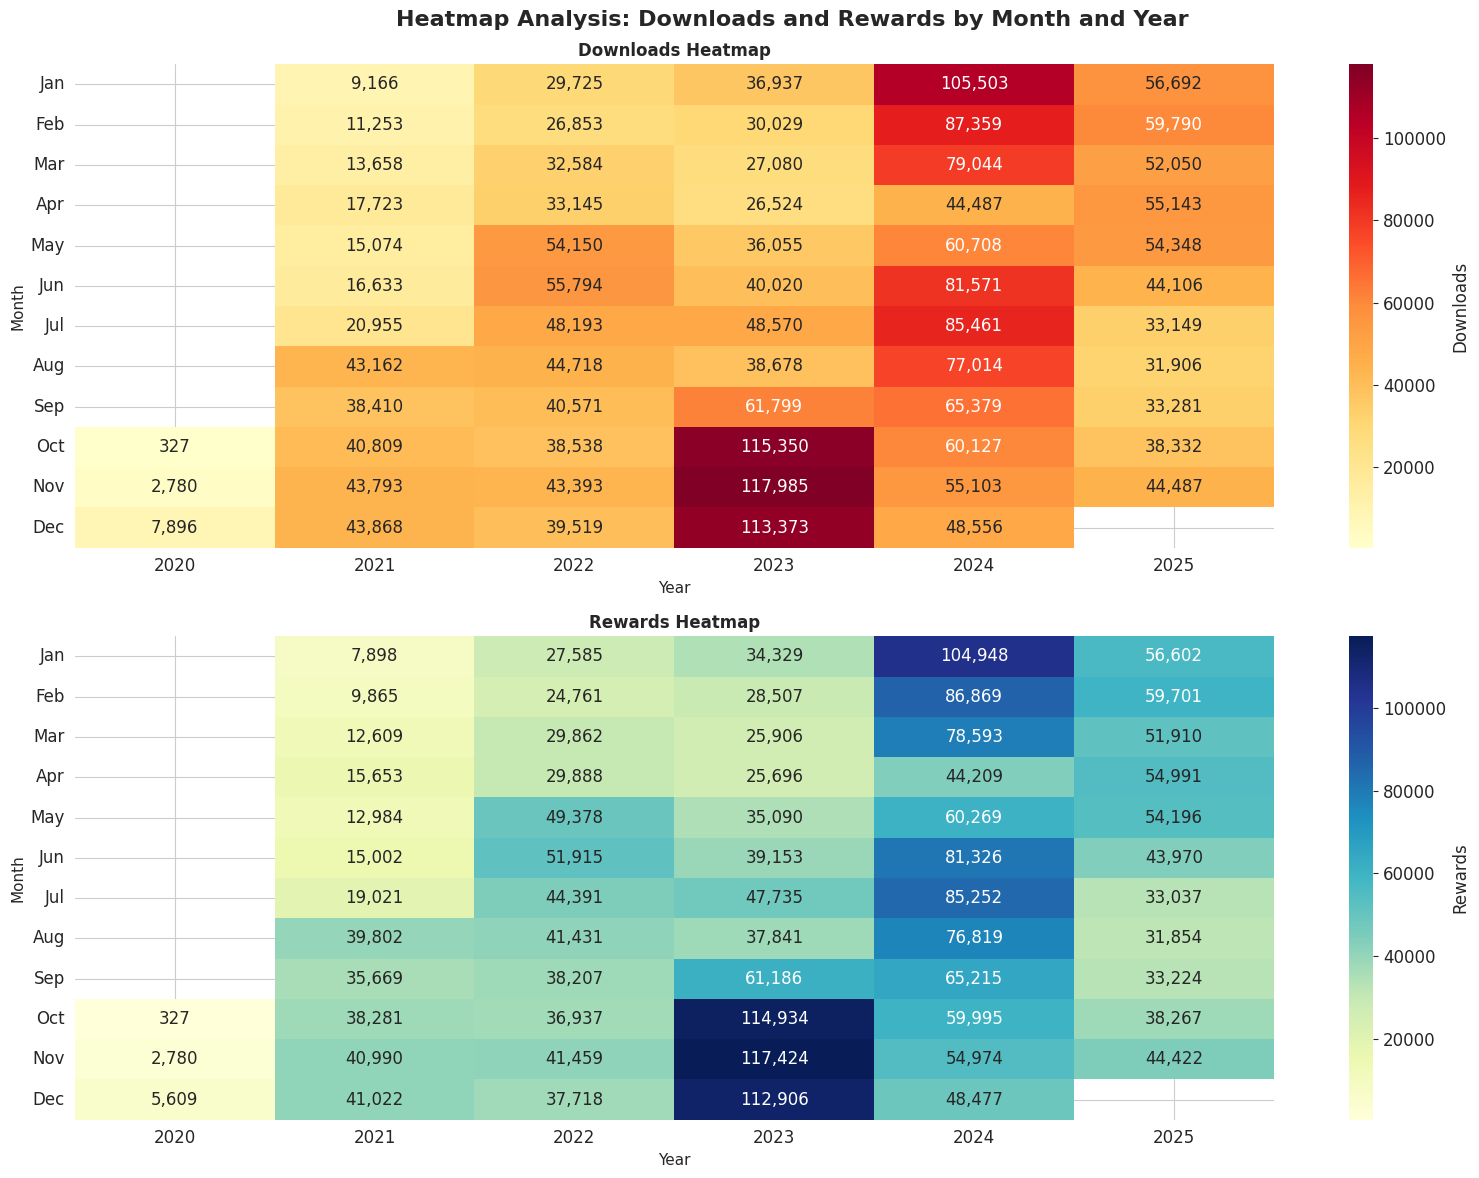


Visualization saved to: analysis_output/heatmap_analysis.png


In [25]:
# Create heatmap visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Heatmap Analysis: Downloads and Rewards by Month and Year', fontsize=16, fontweight='bold')

# Pivot data for heatmap
downloads_pivot = df.pivot_table(values='Downloads', index='Month_Num', columns='Year')
rewards_pivot = df.pivot_table(values='Mod Rewards', index='Month_Num', columns='Year')

# Plot 1: Downloads heatmap
ax1 = axes[0]
sns.heatmap(downloads_pivot, annot=True, fmt=',.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Downloads'}, ax=ax1)
ax1.set_title('Downloads Heatmap', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Month', fontsize=11)
ax1.set_yticklabels([m[:3] for m in month_names], rotation=0)

# Plot 2: Rewards heatmap
ax2 = axes[1]
sns.heatmap(rewards_pivot, annot=True, fmt=',.0f', cmap='YlGnBu', 
            cbar_kws={'label': 'Rewards'}, ax=ax2)
ax2.set_title('Rewards Heatmap', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Month', fontsize=11)
ax2.set_yticklabels([m[:3] for m in month_names], rotation=0)

plt.tight_layout()
plt.savefig(f'{output_dir}/heatmap_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/heatmap_analysis.png")

## 19. Distribution Analysis

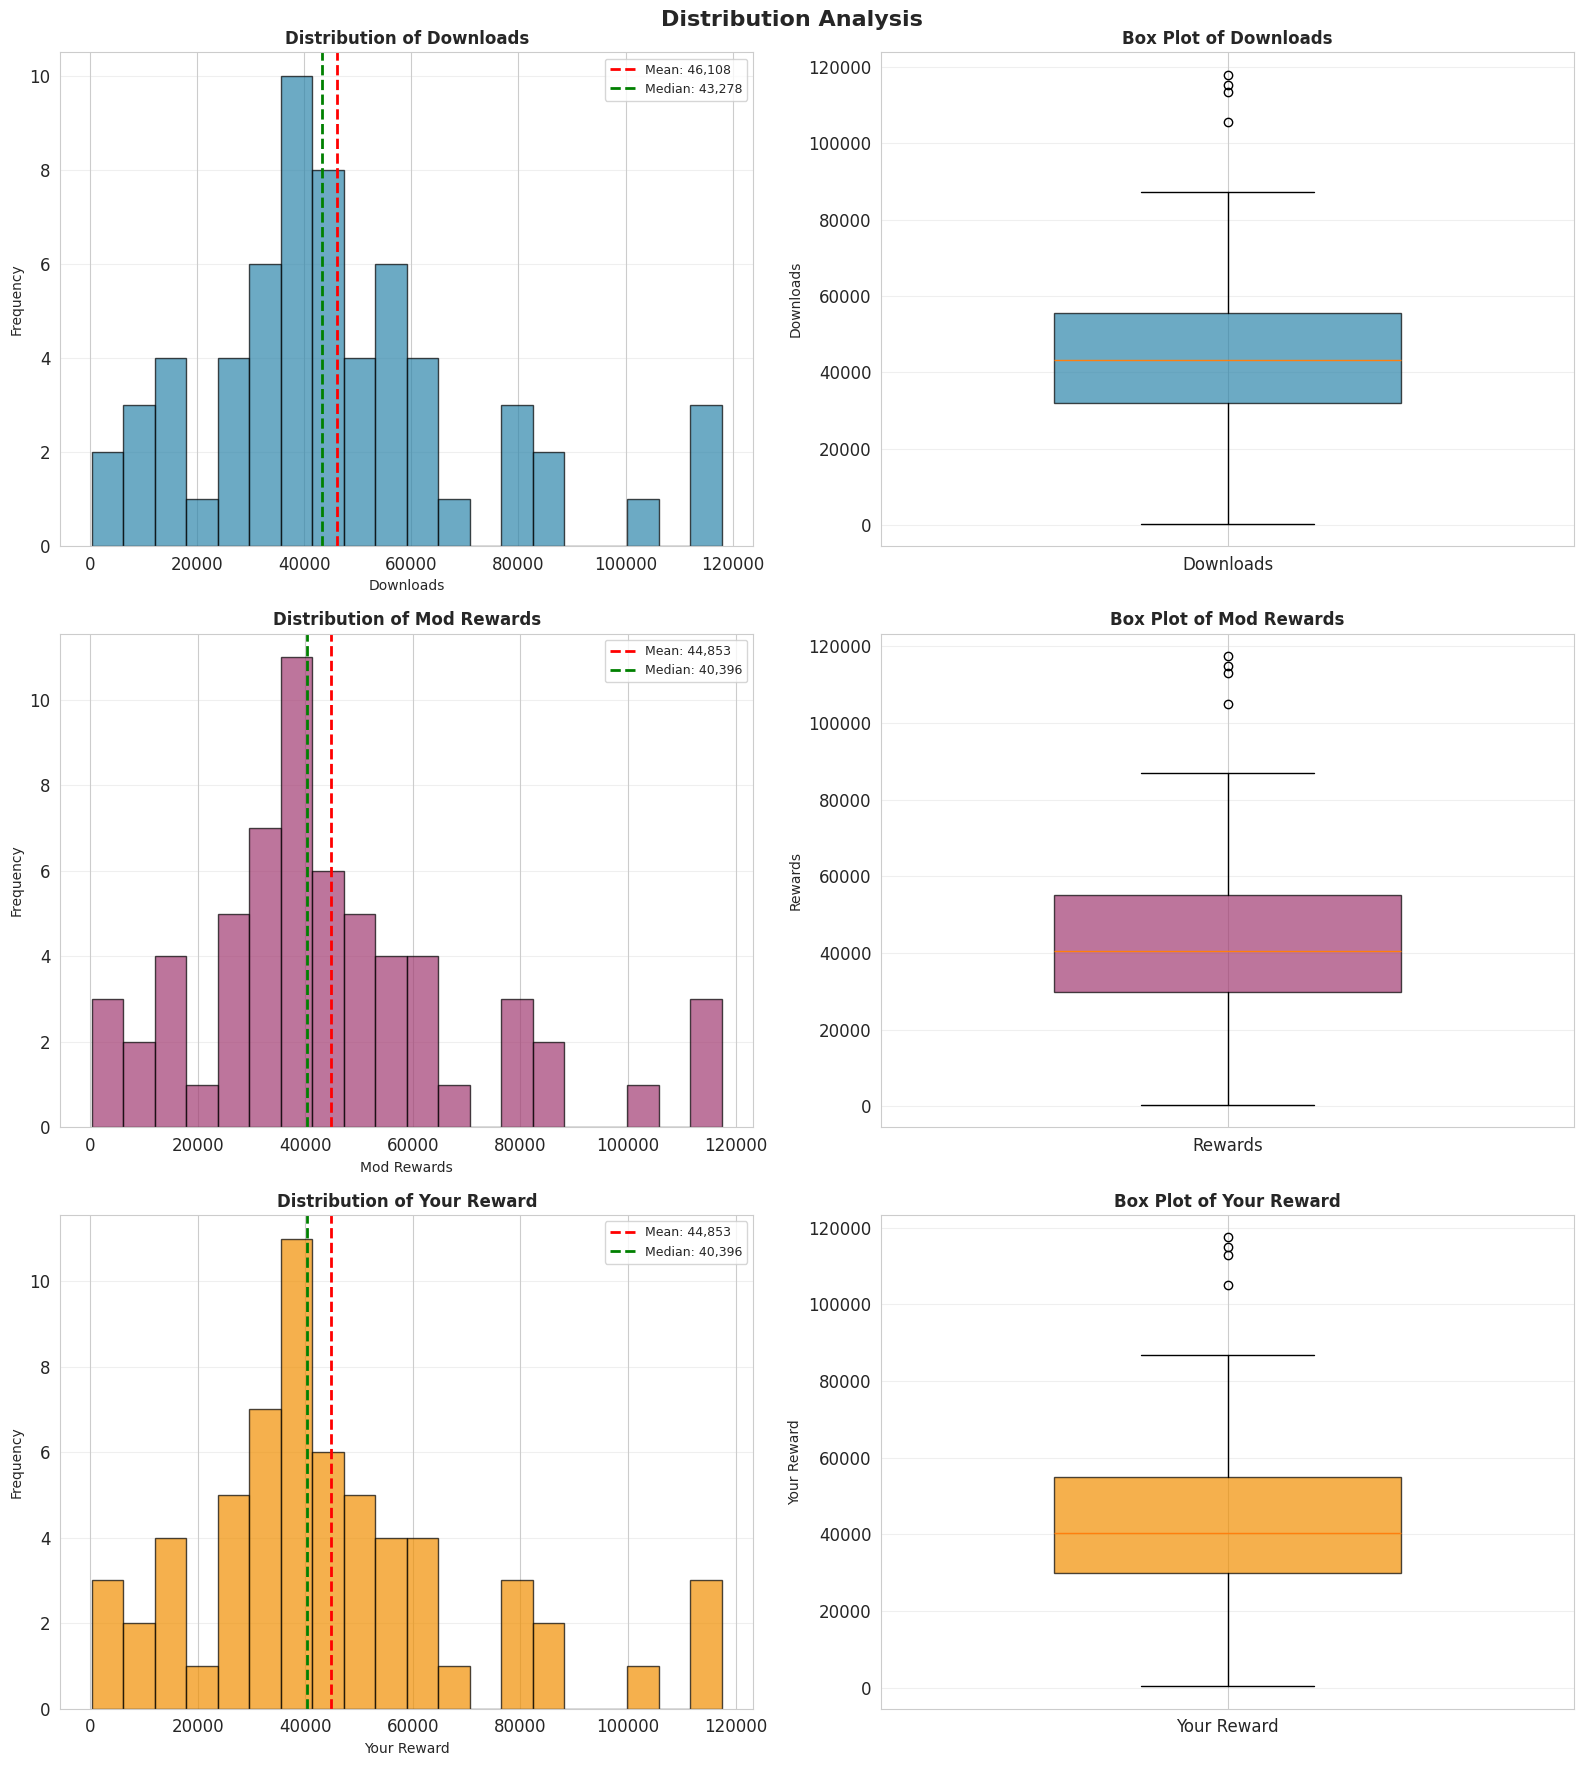


Visualization saved to: analysis_output/distribution_analysis.png


In [26]:
# Create distribution analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Histogram of downloads
ax1 = axes[0, 0]
ax1.hist(df['Downloads'], bins=20, color=COLOR_DOWNLOADS, alpha=0.7, 
         edgecolor='black', linewidth=1)
ax1.axvline(df['Downloads'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_downloads:,.0f}')
ax1.axvline(df['Downloads'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_downloads:,.0f}')
ax1.set_title('Distribution of Downloads', fontsize=12, fontweight='bold')
ax1.set_xlabel('Downloads', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Box plot of downloads
ax2 = axes[0, 1]
bp = ax2.boxplot([df['Downloads']], labels=['Downloads'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(COLOR_DOWNLOADS)
bp['boxes'][0].set_alpha(0.7)
ax2.set_title('Box Plot of Downloads', fontsize=12, fontweight='bold')
ax2.set_ylabel('Downloads', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Histogram of rewards
ax3 = axes[1, 0]
ax3.hist(df['Mod Rewards'], bins=20, color=COLOR_REWARDS, alpha=0.7, 
         edgecolor='black', linewidth=1)
ax3.axvline(df['Mod Rewards'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_rewards:,.0f}')
ax3.axvline(df['Mod Rewards'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_rewards:,.0f}')
ax3.set_title('Distribution of Mod Rewards', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mod Rewards', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot of rewards
ax4 = axes[1, 1]
bp = ax4.boxplot([df['Mod Rewards']], labels=['Rewards'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(COLOR_REWARDS)
bp['boxes'][0].set_alpha(0.7)
ax4.set_title('Box Plot of Mod Rewards', fontsize=12, fontweight='bold')
ax4.set_ylabel('Rewards', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Histogram of Your Reward
ax5 = axes[2, 0]
ax5.hist(df['Your Reward'], bins=20, color=COLOR_YOUR_REWARD, alpha=0.7, 
         edgecolor='black', linewidth=1)
ax5.axvline(df['Your Reward'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_your_reward:,.0f}')
ax5.axvline(df['Your Reward'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_your_reward:,.0f}')
ax5.set_title('Distribution of Your Reward', fontsize=12, fontweight='bold')
ax5.set_xlabel('Your Reward', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Box plot of Your Reward
ax6 = axes[2, 1]
bp = ax6.boxplot([df['Your Reward']], labels=['Your Reward'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(COLOR_YOUR_REWARD)
bp['boxes'][0].set_alpha(0.7)
ax6.set_title('Box Plot of Your Reward', fontsize=12, fontweight='bold')
ax6.set_ylabel('Your Reward', fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{output_dir}/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/distribution_analysis.png")

## 20. Cumulative Analysis

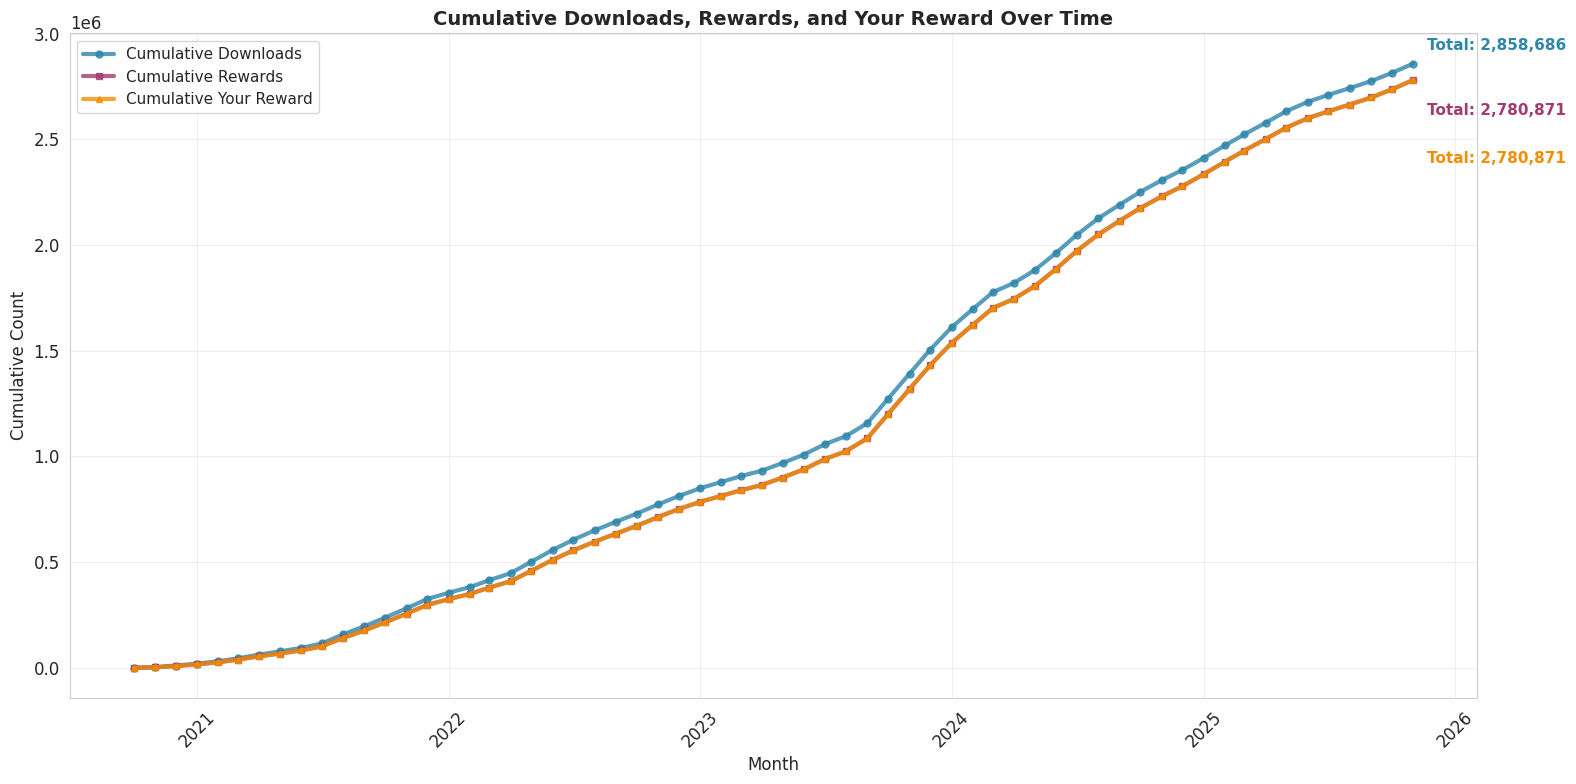


Visualization saved to: analysis_output/cumulative_analysis.png


In [27]:
# Create cumulative analysis
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df.index, df['Cumulative Downloads'], marker='o', linewidth=3, 
        markersize=5, label='Cumulative Downloads', color=COLOR_DOWNLOADS, alpha=0.8)
ax.plot(df.index, df['Cumulative Rewards'], marker='s', linewidth=3, 
        markersize=5, label='Cumulative Rewards', color=COLOR_REWARDS, alpha=0.8)
ax.plot(df.index, df['Cumulative YourReward'], marker='^', linewidth=3, 
        markersize=5, label='Cumulative Your Reward', color=COLOR_YOUR_REWARD, alpha=0.8)

# Add annotations for key milestones
total_downloads_end = df['Cumulative Downloads'].iloc[-1]
total_rewards_end = df['Cumulative Rewards'].iloc[-1]
total_your_reward_end = df['Cumulative YourReward'].iloc[-1]

ax.annotate(f'Total: {total_downloads_end:,}', 
            xy=(df.index[-1], total_downloads_end), 
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color=COLOR_DOWNLOADS)
ax.annotate(f'Total: {total_rewards_end:,}', 
            xy=(df.index[-1], total_rewards_end), 
            xytext=(10, -25), textcoords='offset points',
            fontsize=11, fontweight='bold', color=COLOR_REWARDS)
ax.annotate(f'Total: {total_your_reward_end:,}', 
            xy=(df.index[-1], total_your_reward_end), 
            xytext=(10, -60), textcoords='offset points',
            fontsize=11, fontweight='bold', color=COLOR_YOUR_REWARD)

ax.set_title('Cumulative Downloads, Rewards, and Your Reward Over Time', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cumulative Count', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/cumulative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/cumulative_analysis.png")

## 21. Top and Bottom Performing Months

In [28]:
# Top 5 months by downloads
top_downloads = df.nlargest(5, 'Downloads')[['Downloads', 'Mod Rewards', 'Your Reward']]
top_downloads['Month'] = top_downloads.index.strftime('%B %Y')
top_downloads = top_downloads[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

# Bottom 5 months by downloads
bottom_downloads = df.nsmallest(5, 'Downloads')[['Downloads', 'Mod Rewards', 'Your Reward']]
bottom_downloads['Month'] = bottom_downloads.index.strftime('%B %Y')
bottom_downloads = bottom_downloads[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

# Top 5 months by rewards
top_rewards = df.nlargest(5, 'Mod Rewards')[['Downloads', 'Mod Rewards', 'Your Reward']]
top_rewards['Month'] = top_rewards.index.strftime('%B %Y')
top_rewards = top_rewards[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

# Bottom 5 months by rewards
bottom_rewards = df.nsmallest(5, 'Mod Rewards')[['Downloads', 'Mod Rewards', 'Your Reward']]
bottom_rewards['Month'] = bottom_rewards.index.strftime('%B %Y')
bottom_rewards = bottom_rewards[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

# Top 5 months by Your Reward
top_your_reward = df.nlargest(5, 'Your Reward')[['Downloads', 'Mod Rewards', 'Your Reward']]
top_your_reward['Month'] = top_your_reward.index.strftime('%B %Y')
top_your_reward = top_your_reward[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

# Bottom 5 months by Your Reward
bottom_your_reward = df.nsmallest(5, 'Your Reward')[['Downloads', 'Mod Rewards', 'Your Reward']]
bottom_your_reward['Month'] = bottom_your_reward.index.strftime('%B %Y')
bottom_your_reward = bottom_your_reward[['Month', 'Downloads', 'Mod Rewards', 'Your Reward']]

print("\n" + "="*70)
print("TOP 5 MONTHS BY UNIQUE DOWNLOADS")
print("="*70)
print(top_downloads.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 MONTHS BY UNIQUE DOWNLOADS")
print("="*70)
print(bottom_downloads.to_string(index=False))

print("\n" + "="*70)
print("TOP 5 MONTHS BY MOD REWARDS")
print("="*70)
print(top_rewards.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 MONTHS BY MOD REWARDS")
print("="*70)
print(bottom_rewards.to_string(index=False))

print("\n" + "="*70)
print("TOP 5 MONTHS BY YOUR REWARD")
print("="*70)
print(top_your_reward.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 MONTHS BY YOUR REWARD")
print("="*70)
print(bottom_your_reward.to_string(index=False))


TOP 5 MONTHS BY UNIQUE DOWNLOADS
        Month  Downloads  Mod Rewards  Your Reward
November 2023     117985       117424       117424
 October 2023     115350       114934       114934
December 2023     113373       112906       112906
 January 2024     105503       104948       104948
February 2024      87359        86869        86869

BOTTOM 5 MONTHS BY UNIQUE DOWNLOADS
        Month  Downloads  Mod Rewards  Your Reward
 October 2020        327          327          327
November 2020       2780         2780         2780
December 2020       7896         5609         5609
 January 2021       9166         7898         7898
February 2021      11253         9865         9865

TOP 5 MONTHS BY MOD REWARDS
        Month  Downloads  Mod Rewards  Your Reward
November 2023     117985       117424       117424
 October 2023     115350       114934       114934
December 2023     113373       112906       112906
 January 2024     105503       104948       104948
February 2024      87359        8

## 22. Save Processed Data to Output Directory

In [29]:
# Save cleaned DataFrame to CSV
output_csv = f'{output_dir}/nexusmods_rewards_processed.csv'
df.to_csv(output_csv)

# Save with growth rates and moving averages
df_with_analysis = df.copy()
df_with_analysis['Month'] = df_with_analysis.index.strftime('%Y-%m-%d')
df_with_analysis = df_with_analysis.reset_index(drop=True)
df_with_analysis.to_csv(f'{output_dir}/nexusmods_rewards_full_analysis.csv', index=False)

# Save forecast data
forecast_df = pd.DataFrame({
    'Month': dl_forecast_dates.strftime('%Y-%m-%d'),
    'Downloads Forecast': dl_forecast_values.values,
    'Downloads Lower CI': dl_confidence['lower'].values,
    'Downloads Upper CI': dl_confidence['upper'].values,
    'Rewards Forecast': rw_forecast_values.values,
    'Rewards Lower CI': rw_confidence['lower'].values,
    'Rewards Upper CI': rw_confidence['upper'].values,
    'YourReward Forecast': yr_forecast_values.values,
    'YourReward Lower CI': yr_confidence['lower'].values,
    'YourReward Upper CI': yr_confidence['upper'].values
})
forecast_df.to_csv(f'{output_dir}/nexusmods_forecast.csv', index=False)

# Save monthly averages (seasonal patterns)
monthly_avg.to_csv(f'{output_dir}/nexusmods_monthly_averages.csv')

# Save yearly statistics
yearly_stats = df.groupby('Year').agg({
    'Downloads': ['sum', 'mean', 'std'],
    'Mod Rewards': ['sum', 'mean', 'std'],
    'Your Reward': ['sum', 'mean', 'std']
}).round(2)
yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns.values]
yearly_stats.to_csv(f'{output_dir}/nexusmods_yearly_stats.csv')

print(f"\nAll data files saved to: {output_dir}/")
print(f"  - nexusmods_rewards_processed.csv")
print(f"  - nexusmods_rewards_full_analysis.csv")
print(f"  - nexusmods_forecast.csv")
print(f"  - nexusmods_monthly_averages.csv")
print(f"  - nexusmods_yearly_stats.csv")
print(f"  - nexusmods_quarterly_stats.csv")

print(f"\nTotal records: {len(df)}")
print(f"Date range: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")


All data files saved to: analysis_output/
  - nexusmods_rewards_processed.csv
  - nexusmods_rewards_full_analysis.csv
  - nexusmods_forecast.csv
  - nexusmods_monthly_averages.csv
  - nexusmods_yearly_stats.csv
  - nexusmods_quarterly_stats.csv

Total records: 62
Date range: October 2020 to November 2025


## 23. Final Summary Report

In [30]:
# Find best and worst performing months on average
best_month_downloads = monthly_avg.loc[monthly_avg['Downloads'].idxmax()]
worst_month_downloads = monthly_avg.loc[monthly_avg['Downloads'].idxmin()]
best_month_rewards = monthly_avg.loc[monthly_avg['Mod Rewards'].idxmax()]
worst_month_rewards = monthly_avg.loc[monthly_avg['Mod Rewards'].idxmin()]

# Generate final summary report
print("\n" + "="*80)
print("NEXUS MODS REWARDS ANALYSIS")
print("="*80)
print(f"\nAnalysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nDATA OVERVIEW:")
print(f"  - Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"  - Total Months: {len(df)}")
print(f"  - Data Points: {len(df) * 3} (downloads + rewards + your reward)")
print(f"  - Years Covered: {len(df['Year'].unique())}")

print(f"\nKEY METRICS:")
print(f"  - Total Mod Rewards: {total_rewards:,} points")
print(f"  - Total Your Reward: {total_your_reward:,} points")
print(f"  - Your Reward Share: {(total_your_reward/total_rewards)*100:.2f}%")
print(f"  - Total Downloads: {total_downloads:,}")
print(f"  - Average Monthly Downloads: {mean_downloads:,.2f}")
print(f"  - Average Monthly Rewards: {mean_rewards:,.2f}")
print(f"  - Median Monthly Downloads: {median_downloads:,.2f}")
print(f"  - Median Monthly Rewards: {median_rewards:,.2f}")

print(f"\nVOLATILITY ANALYSIS:")
print(f"  - Downloads Std Dev: {std_downloads:,.2f}")
print(f"  - Downloads CV: {(std_downloads/mean_downloads)*100:.2f}%")
print(f"  - Rewards Std Dev: {std_rewards:,.2f}")
print(f"  - Rewards CV: {(std_rewards/mean_rewards)*100:.2f}%")

print(f"\nREWARD EFFICIENCY:")
print(f"  - Average Rewards per Download: {avg_rewards_per_download:.4f}")
print(f"  - Average Your Reward Share: {avg_your_reward_share:.2f}%")

print(f"\nPEAK PERFORMANCE:")
print(f"  - Highest Downloads: {peak_downloads_value:,} ({peak_downloads_month.strftime('%B %Y')})")
print(f"  - Highest Rewards: {peak_rewards_value:,} ({peak_rewards_month.strftime('%B %Y')})")
print(f"  - Lowest Downloads: {lowest_downloads_value:,} ({lowest_downloads_month.strftime('%B %Y')})")

print(f"\nGROWTH ANALYSIS:")
print(f"  - Average Monthly Growth (Downloads): {avg_monthly_growth_downloads:.2f}%")
print(f"  - Average Monthly Growth (Rewards): {avg_monthly_growth_rewards:.2f}%")
print(f"  - Average YoY Growth (Downloads): {avg_yoy_growth_downloads:.2f}%")
print(f"  - Average YoY Growth (Rewards): {avg_yoy_growth_rewards:.2f}%")

print(f"\nCORRELATION ANALYSIS:")
print(f"  - Downloads-Rewards Correlation: {correlation:.4f}")
print(f"  - Downloads-YourReward Correlation: {your_reward_correlation:.4f}")
print(f"  - Correlation Strength: {'Very Strong' if abs(correlation) > 0.8 else 'Strong' if abs(correlation) > 0.6 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'}")

print(f"\nTREND ANALYSIS (Mann-Kendall Test):")
print(f"  - Downloads Trend: {mk_downloads['trend']} (p-value: {mk_downloads['p_value']:.4f})")
print(f"  - Rewards Trend: {mk_rewards['trend']} (p-value: {mk_rewards['p_value']:.4f})")
print(f"  - Your Reward Trend: {mk_your_reward['trend']} (p-value: {mk_your_reward['p_value']:.4f})")

print(f"\nOUTLIER ANALYSIS:")
print(f"  - Downloads Outliers Detected: {df['Downloads Outlier'].sum()} months")
print(f"  - Rewards Outliers Detected: {df['Rewards Outlier'].sum()} months")
print(f"  - Your Reward Outliers Detected: {df['YourReward Outlier'].sum()} months")
print(f"  - Outlier Detection Methods: IQR ({IQR_MULTIPLIER}x) and Z-score ({ZSCORE_THRESHOLD})")

print(f"\nFORECASTING:")
print(f"  - Forecast Period: {FORECAST_PERIODS} months")
print(f"  - Forecast Methods: Linear Trend and {MA_WINDOW_SHORT}-Month Moving Average")
print(f"  - Confidence Interval: 95%")
print(f"  - Forecast Start: {df.index[-1].strftime('%B %Y')}")

print(f"\nSEASONAL INSIGHTS:")
print(f"  - Best Month for Downloads: {best_month_downloads['Month_Name']} (avg: {best_month_downloads['Downloads']:,.0f})")
print(f"  - Worst Month for Downloads: {worst_month_downloads['Month_Name']} (avg: {worst_month_downloads['Downloads']:,.0f})")
print(f"  - Best Month for Rewards: {best_month_rewards['Month_Name']} (avg: {best_month_rewards['Mod Rewards']:,.0f})")
print(f"  - Worst Month for Rewards: {worst_month_rewards['Month_Name']} (avg: {worst_month_rewards['Mod Rewards']:,.0f})")

print(f"\nOUTPUT FILES GENERATED:")
print(f"  All files saved to: {output_dir}/")
print(f"  \nCSV Files:")
print(f"    1. nexusmods_rewards_processed.csv - Cleaned data")
print(f"    2. nexusmods_rewards_full_analysis.csv - Data with all analysis columns")
print(f"    3. nexusmods_forecast.csv - Forecast data with confidence intervals")
print(f"    4. nexusmods_monthly_averages.csv - Monthly averages (seasonal patterns)")
print(f"    5. nexusmods_yearly_stats.csv - Yearly statistics")
print(f"    6. nexusmods_quarterly_stats.csv - Quarterly statistics")

print(f"  \nPNG Visualizations:")
print(f"    1. moving_averages_with_outliers.png - Time series with outliers highlighted")
print(f"    2. forecast_analysis.png - 6-month forecast with confidence intervals")
print(f"    3. growth_rates.png - Monthly growth rate analysis")
print(f"    4. correlation_analysis.png - Downloads vs Rewards correlation")
print(f"    5. reward_efficiency.png - Reward efficiency analysis")
print(f"    6. rolling_correlation.png - Rolling correlation analysis")
print(f"    7. seasonal_patterns.png - Seasonal patterns analysis")
print(f"    8. year_over_year.png - Year-over-year comparison")
print(f"    9. heatmap_analysis.png - Heatmap visualization")
print(f"    10. distribution_analysis.png - Distribution analysis with box plots")
print(f"    11. cumulative_analysis.png - Cumulative totals over time")

print("\n" + "="*80)


NEXUS MODS REWARDS ANALYSIS

Analysis Date: 2026-01-15 21:27:16

DATA OVERVIEW:
  - Period: October 2020 to November 2025
  - Total Months: 62
  - Data Points: 186 (downloads + rewards + your reward)
  - Years Covered: 6

KEY METRICS:
  - Total Mod Rewards: 2,780,871 points
  - Total Your Reward: 2,780,871 points
  - Your Reward Share: 100.00%
  - Total Downloads: 2,858,686
  - Average Monthly Downloads: 46,107.84
  - Average Monthly Rewards: 44,852.76
  - Median Monthly Downloads: 43,277.50
  - Median Monthly Rewards: 40,396.00

VOLATILITY ANALYSIS:
  - Downloads Std Dev: 26,173.13
  - Downloads CV: 56.77%
  - Rewards Std Dev: 26,513.89
  - Rewards CV: 59.11%

REWARD EFFICIENCY:
  - Average Rewards per Download: 0.9577
  - Average Your Reward Share: 100.00%

PEAK PERFORMANCE:
  - Highest Downloads: 117,985 (November 2023)
  - Highest Rewards: 117,424 (November 2023)
  - Lowest Downloads: 327 (October 2020)

GROWTH ANALYSIS:
  - Average Monthly Growth (Downloads): 20.87%
  - Average M